<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/BERT_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 BERT 완전정복 - 비전공자를 위한 친절한 가이드

> **"문장의 의미를 이해하는 AI, BERT를 배워봅시다"**

## 🌟 이 노트북에서 배울 것
- **BERT가 무엇인지** 비유를 통해 이해하기
- **BERT가 문장을 어떻게 읽는지** 단계별로 살펴보기
- **실습 4가지** 직접 만들어보기:
  1. 😊 **감정 분류**: 영화 리뷰가 긍정인지 부정인지 판별
  2. 🏷️ **개체 태깅 (NER)**: 문장에서 사람/장소/회사 이름 찾기
  3. 📏 **문장 비교 (STS)**: 두 문장이 얼마나 비슷한지 측정
  4. ❓ **질문 답변 (QA)**: 지문을 읽고 질문에 답하기

## 📌 이 노트북의 특징
- ✅ **친근한 비유**로 어려운 개념도 쉽게
- ✅ **풍부한 시각화**로 눈으로 보고 이해
- ✅ **빈칸 채우기 실습**으로 직접 코드 작성
- ✅ **단계별 퀴즈**로 이해도 점검
- ✅ **Google Colab** 환경에서 바로 실행 가능

> 💡 **참고**: Transformer를 먼저 공부하고 오시면 더 이해가 잘 됩니다!
> BERT는 Transformer의 인코더(Encoder) 부분만 가져다 쓰는 모델이에요.

---

## 📚 전체 목차
| 섹션 | 제목 | 핵심 내용 |
|------|------|----------|
| 1 | 🛠️ 환경 설정 | 라이브러리 설치 |
| 2 | 🤔 BERT가 뭔가요? | 개념과 비유 |
| 3 | ✂️ BERT 토크나이저 | 단어를 쪼개는 방법 |
| 4 | 🧱 BERT의 입력 구조 | 3가지 임베딩 |
| 5 | 🎭 MLM (빈칸 맞추기) | 사전학습 방법 1 |
| 6 | 🔗 NSP (이어지는 문장?) | 사전학습 방법 2 |
| 7 | 🎯 파인튜닝이란? | 응용 학습 |
| 8 | 😊 실습 1: 감정 분류 | Sentiment Analysis |
| 9 | 🏷️ 실습 2: 개체 태깅 | Named Entity Recognition |
| 10 | 📏 실습 3: 문장 비교 | Semantic Textual Similarity |
| 11 | ❓ 실습 4: 질문 답변 | Question Answering |
| 12 | 🚀 최신 BERT 친구들 | RoBERTa, ELECTRA 등 |


---
# 1️⃣ 환경 설정

## 🛠️ 필요한 도구들

요리하기 전에 칼·도마·냄비를 준비하듯이, BERT를 다루기 위해 라이브러리를 설치합니다.

| 도구 | 역할 | 비유 |
|------|------|------|
| `transformers` | BERT 모델 자체 | 🧠 두뇌 |
| `datasets` | 학습 데이터 | 📖 교과서 |
| `torch` | 계산 엔진 | ⚙️ 모터 |
| `matplotlib` | 그래프 그리기 | 🎨 그림 도구 |
| `seaborn` | 예쁜 그래프 | 🌈 색칠 도구 |

> 💡 **Colab 사용자**: 아래 셀을 실행하면 자동으로 설치됩니다.

In [1]:
# 📦 필수 라이브러리 설치 (Colab에서 자동 설치됨)
!pip install -q transformers datasets torch matplotlib seaborn scikit-learn

print("✅ 설치 완료!")

✅ 설치 완료!


In [2]:
# 📚 라이브러리 불러오기
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, BertTokenizer, BertModel

# 한글 폰트 + 음수 부호 + 수식 폰트 (1-4 패턴)
import subprocess
try:
    subprocess.run(['apt-get','-qq','install','fonts-nanum'], check=False)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
except Exception as e:
    print(f"폰트 생략: {e}")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'


# 디바이스 설정 (GPU가 있으면 GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 사용 장치: {device}")
print(f"🔥 PyTorch 버전: {torch.__version__}")
print("✅ 환경 설정 완료")

🖥️ 사용 장치: cuda
🔥 PyTorch 버전: 2.10.0+cu128
✅ 환경 설정 완료


### ✅ 체크포인트 1

여기까지 잘 실행되었다면 BERT를 다룰 준비가 끝났습니다! 🎉

> ⚠️ 만약 에러가 났다면 **런타임 → 런타임 다시 시작**을 눌러보세요.

---
# 2️⃣ BERT가 뭔가요?

## 🤔 BERT를 한 문장으로 말하면?

> **"문장의 양쪽 방향을 동시에 읽어서 의미를 파악하는 AI"**

**B**idirectional **E**ncoder **R**epresentations from **T**ransformers
= **양방향**으로 **인코더**가 표현을 만들어내는 **트랜스포머**

## 🆚 비유로 이해하기: BERT vs GPT

### 📖 책 읽는 두 가지 방법

#### 1️⃣ **GPT** = 한 방향으로만 읽는 사람
> "옛날 옛적에 한 마을에..." → 다음 단어를 예측
- 왼쪽에서 오른쪽으로 순서대로
- 문장 생성에 강함 ✍️

#### 2️⃣ **BERT** = 양쪽으로 동시에 읽는 사람
> "옛날 옛적에 한 ___에 살았다" → 빈칸 앞뒤 모두 봄
- 빈칸 채우기 시험을 푸는 학생처럼
- 문장 **이해**에 강함 🧐

## 🎯 BERT의 핵심 아이디어

**"문장의 의미를 제대로 이해하려면, 단어의 앞뒤를 모두 봐야 한다!"**

예시:
- "그 **배**가 정말 맛있어" → 배(과일) 🍐
- "그 **배**가 항구에 도착했어" → 배(선박) 🚢

같은 단어 '배'라도 **앞뒤 문맥**을 봐야 정확한 의미를 알 수 있죠!

## 🏗️ BERT의 학습 과정 (2단계)

BERT는 **두 단계**로 학습됩니다:

### 1단계: 사전학습 (Pre-training) 🎓
**"엄청 많은 책을 읽고 일반적인 언어 능력 키우기"**
- 위키피디아 + 책 = 33억 단어로 학습
- 빈칸 채우기 게임 (MLM) + 다음 문장 맞히기 (NSP)
- 시간: 며칠~몇 주 (구글이 미리 해놓음! 💪)

### 2단계: 파인튜닝 (Fine-tuning) 🎯
**"특정 직무 교육 받기"**
- 사전학습된 BERT를 가져와서
- 우리가 원하는 작업(감정 분류, NER 등)에 맞게 추가 학습
- 시간: 몇 분~몇 시간

### 📊 비유: 대학교 졸업 → 회사 입사

| 단계 | 비유 | BERT |
|------|------|------|
| 사전학습 | 4년간 대학교에서 일반 교양 공부 | 33억 단어로 언어 학습 |
| 파인튜닝 | 회사 입사 후 직무 교육 | 특정 작업용 추가 학습 |

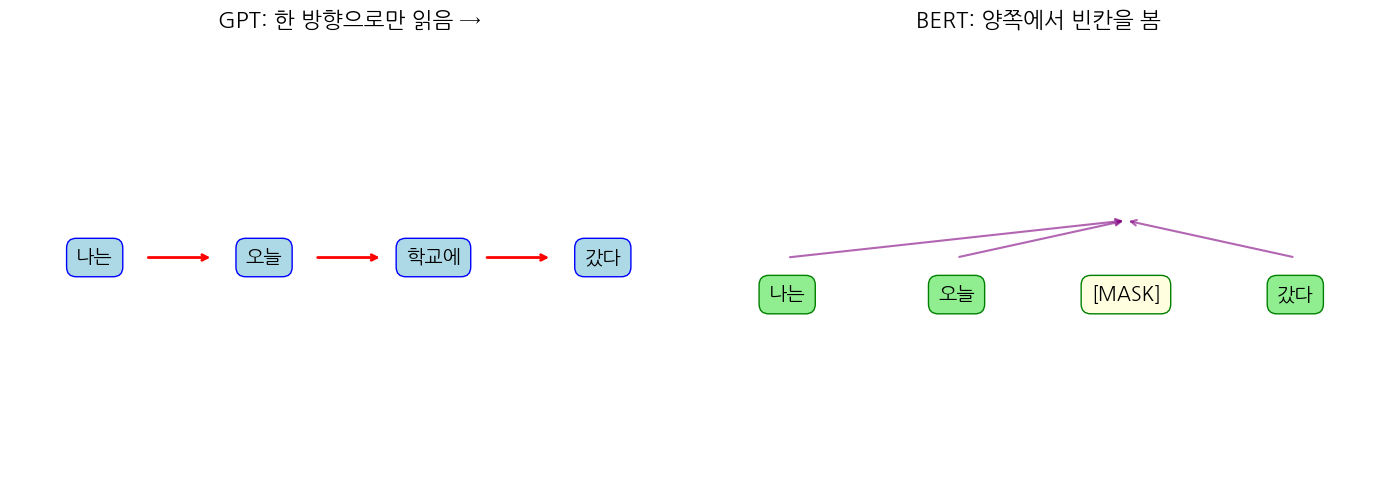


🔍 GPT는 다음 단어를 예측하느라 한 방향만 봅니다.
🔍 BERT는 빈칸의 좌우 단어들을 모두 보고 무엇이 들어갈지 맞춥니다.


In [3]:
# 🎨 BERT vs GPT 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GPT (왼→오)
ax1 = axes[0]
words = ['나는', '오늘', '학교에', '갔다']
for i, w in enumerate(words):
    ax1.text(i, 0.5, w, ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='blue'))
    if i < len(words) - 1:
        ax1.annotate('', xy=(i+0.7, 0.5), xytext=(i+0.3, 0.5),
                     arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.set_xlim(-0.5, len(words)-0.5)
ax1.set_ylim(0, 1)
ax1.set_title('GPT: 한 방향으로만 읽음 →', fontsize=16, fontweight='bold')
ax1.axis('off')

# BERT (양방향)
ax2 = axes[1]
for i, w in enumerate(words):
    color = 'lightyellow' if i == 2 else 'lightgreen'
    label = '[MASK]' if i == 2 else w
    ax2.text(i, 0.5, label, ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='green'))

# 양방향 화살표
for i in range(len(words)):
    if i != 2:
        ax2.annotate('', xy=(2, 0.7), xytext=(i, 0.6),
                     arrowprops=dict(arrowstyle='->', color='purple', lw=1.5, alpha=0.6))

ax2.set_xlim(-0.5, len(words)-0.5)
ax2.set_ylim(0, 1.2)
ax2.set_title('BERT: 양쪽에서 빈칸을 봄 ', fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n🔍 GPT는 다음 단어를 예측하느라 한 방향만 봅니다.")
print("🔍 BERT는 빈칸의 좌우 단어들을 모두 보고 무엇이 들어갈지 맞춥니다.")

## 🧠 퀴즈 #1

다음 중 BERT의 특징이 **아닌** 것은?

- A) 양방향으로 문장을 읽는다
- B) 다음에 올 단어를 예측하면서 학습한다
- C) Transformer의 인코더 부분을 사용한다
- D) 사전학습 후 파인튜닝으로 다양한 작업에 사용한다

<details>
<summary>👉 정답 보기</summary>

**B) 다음에 올 단어를 예측하면서 학습한다**
- 그건 GPT의 학습 방식이에요!
- BERT는 **빈칸 맞추기(MLM)** 와 **문장 이어짐 판단(NSP)** 으로 학습합니다.

</details>

---
# 3️⃣ BERT 토크나이저 (WordPiece)

## ✂️ 토큰화란?

> **"문장을 컴퓨터가 이해할 수 있는 작은 조각으로 나누는 작업"**

컴퓨터는 글자를 못 읽기 때문에, 단어를 **숫자**로 바꿔야 해요.

## 🧩 비유: 레고 블록

긴 단어를 한 덩어리로 보지 않고, **레고 블록처럼 작은 조각**으로 나눕니다.

| 원래 단어 | WordPiece 토큰 | 이유 |
|----------|----------------|------|
| playing | play + ##ing | 'play'와 '~ing' 형태 분리 |
| unhappiness | un + ##happiness | 'un-' 접두사 분리 |
| 코로나19 | 코로나 + ##19 | 한국어도 작게 쪼갬 |

> 💡 **`##` 표시**는 "앞 토큰에 붙는 조각"이라는 뜻이에요.

## 🎯 왜 이렇게 쪼갤까요?

**문제**: 영어 단어가 수십만 개인데 다 외울 수 없음!
**해결**: 자주 쓰는 조각만 외우고, 조립해서 사용!

- "running", "runs", "runner" → 모두 "run + ##~"으로 표현 가능
- 처음 보는 단어도 조각으로 표현 가능

## 🔑 BERT의 특수 토큰

| 토큰 | 의미 | 비유 |
|------|------|------|
| `[CLS]` | 문장의 시작, 전체 요약 | 📋 반장 (전체 대표) |
| `[SEP]` | 문장 끝 / 문장 구분 | 🚧 구분선 |
| `[MASK]` | 가려진 단어 (빈칸) | ⬛ 검은 박스 |
| `[PAD]` | 빈자리 채우기 | 📦 충전재 |
| `[UNK]` | 모르는 단어 | ❓ 물음표 |

In [4]:
# 🔧 BERT 토크나이저 로드
# bert-base-uncased = 영어 BERT (소문자만 사용)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print(f"📊 어휘 사전 크기: {tokenizer.vocab_size:,}개 토큰")
print(f"🎯 특수 토큰들:")
print(f"   [CLS]: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"   [SEP]: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
print(f"   [MASK]: {tokenizer.mask_token} (ID: {tokenizer.mask_token_id})")
print(f"   [PAD]: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"   [UNK]: {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


📊 어휘 사전 크기: 30,522개 토큰
🎯 특수 토큰들:
   [CLS]: [CLS] (ID: 101)
   [SEP]: [SEP] (ID: 102)
   [MASK]: [MASK] (ID: 103)
   [PAD]: [PAD] (ID: 0)
   [UNK]: [UNK] (ID: 100)


In [5]:
# 🧪 토큰화 실험: 다양한 문장을 쪼개보자
sentences = [
    "I love machine learning!",
    "BERT is unbelievable.",
    "Tokenization splits words.",
    "Playing football is fun."
]

for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    print(f"📝 원문: {sent}")
    print(f"🧩 토큰: {tokens}")
    print(f"🔢 토큰 개수: {len(tokens)}개")
    print("-" * 60)

📝 원문: I love machine learning!
🧩 토큰: ['i', 'love', 'machine', 'learning', '!']
🔢 토큰 개수: 5개
------------------------------------------------------------
📝 원문: BERT is unbelievable.
🧩 토큰: ['bert', 'is', 'unbelievable', '.']
🔢 토큰 개수: 4개
------------------------------------------------------------
📝 원문: Tokenization splits words.
🧩 토큰: ['token', '##ization', 'splits', 'words', '.']
🔢 토큰 개수: 5개
------------------------------------------------------------
📝 원문: Playing football is fun.
🧩 토큰: ['playing', 'football', 'is', 'fun', '.']
🔢 토큰 개수: 5개
------------------------------------------------------------


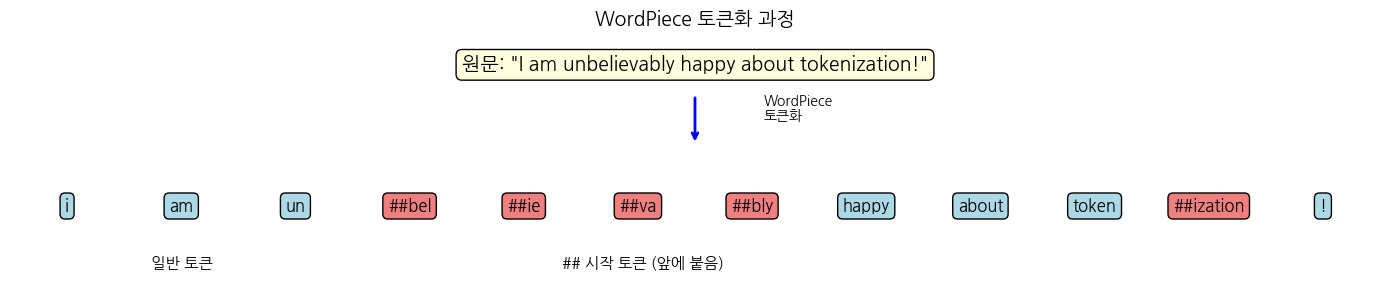


💡 'unbelievably' 같은 긴 단어는 'un + ##believ + ##ably'로 쪼개졌어요!


In [6]:
# 🎨 토큰화 결과 시각화
sentence = "I am unbelievably happy about tokenization!"
tokens = tokenizer.tokenize(sentence)

fig, ax = plt.subplots(figsize=(14, 3))

# 원문
ax.text(0.5, 0.85, f"원문: \"{sentence}\"",
        ha='center', fontsize=14, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow'))

# 화살표
ax.annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.75),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(0.55, 0.65, 'WordPiece\n토큰화', transform=ax.transAxes, fontsize=10)

# 토큰
n = len(tokens)
for i, t in enumerate(tokens):
    color = 'lightcoral' if t.startswith('##') else 'lightblue'
    x = (i + 0.5) / n
    ax.text(x, 0.3, t, ha='center', va='center', fontsize=12,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='black'))

# 범례
ax.text(0.1, 0.05, ' 일반 토큰', transform=ax.transAxes, fontsize=11)
ax.text(0.4, 0.05, ' ## 시작 토큰 (앞에 붙음)', transform=ax.transAxes, fontsize=11)

ax.axis('off')
plt.title('WordPiece 토큰화 과정', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 'unbelievably' 같은 긴 단어는 'un + ##believ + ##ably'로 쪼개졌어요!")

## 🔢 토큰 → 숫자 변환

토큰화한 후엔 각 토큰을 **사전(vocab)에 있는 번호**로 바꿉니다.

비유: 사전에서 단어를 찾아 페이지 번호를 적는 것과 같아요. 📚

In [7]:
# 🎯 토큰을 ID(숫자)로 변환
sentence = "I love BERT!"

# 방법 1: 단계별로 보기
tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("📝 원문:", sentence)
print("🧩 토큰:", tokens)
print("🔢 ID:  ", token_ids)
print()

# 방법 2: 한 번에 + 특수 토큰 자동 추가
encoded = tokenizer(sentence, return_tensors='pt')
print("📦 BERT 입력 형태 (특수 토큰 포함):")
print(f"   input_ids: {encoded['input_ids'][0].tolist()}")
print(f"   tokens:    {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])}")
print()
print("💡 자동으로 [CLS]와 [SEP]가 추가되었어요!")

📝 원문: I love BERT!
🧩 토큰: ['i', 'love', 'bert', '!']
🔢 ID:   [1045, 2293, 14324, 999]

📦 BERT 입력 형태 (특수 토큰 포함):
   input_ids: [101, 1045, 2293, 14324, 999, 102]
   tokens:    ['[CLS]', 'i', 'love', 'bert', '!', '[SEP]']

💡 자동으로 [CLS]와 [SEP]가 추가되었어요!


## 🎯 빈칸 채우기 실습 #1

아래 코드의 `____` 부분을 채워서 문장을 토큰화하고 ID로 변환해보세요!

> 🔍 **힌트**: `tokenizer.tokenize()`와 `tokenizer.convert_tokens_to_ids()`를 사용하세요.

In [8]:
# 🎯 실습 #1: 직접 토큰화해보기
sentence = "Tokenizers are amazing tools!"

# TODO: 1. 문장을 토큰으로 쪼개세요
tokens = tokenizer.tokenize(sentence)

# TODO: 2. 토큰을 ID로 변환하세요
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"원문: {sentence}")
print(f"토큰: {tokens}")
print(f"IDs:  {token_ids}")

원문: Tokenizers are amazing tools!
토큰: ['token', '##izer', '##s', 'are', 'amazing', 'tools', '!']
IDs:  [19204, 17629, 2015, 2024, 6429, 5906, 999]


<details>
<summary>🔑 정답 보기</summary>

```python
tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
```

- `tokenizer.tokenize()`: 문장을 토큰 조각으로 나눕니다.
- `tokenizer.convert_tokens_to_ids()`: 토큰 → ID 번호로 변환합니다.

</details>

### ✅ 체크포인트 2

지금까지 배운 것:
- BERT는 **양방향**으로 문장을 읽는 AI
- BERT는 **사전학습 + 파인튜닝** 2단계로 만들어짐
- 토크나이저는 단어를 **WordPiece 조각**으로 쪼갬
- 특수 토큰 `[CLS]`, `[SEP]`, `[MASK]` 등이 사용됨

---
# 4️⃣ BERT의 입력 구조 (3가지 임베딩)

## 🧱 BERT에 들어가는 입력은 세 겹 샌드위치!

BERT는 단어 하나하나를 **3가지 정보**의 합으로 표현해요.

### 🥪 BERT 입력 = 토큰 + 위치 + 세그먼트

| 임베딩 | 역할 | 비유 |
|--------|------|------|
| **Token Embedding** | 단어 자체의 의미 | 🍞 빵 (기본) |
| **Position Embedding** | 단어의 순서 | 🥩 고기 (위치 정보) |
| **Segment Embedding** | 어느 문장에 속하는지 | 🥬 야채 (문장 구분) |

이 세 가지를 **그냥 더해서** BERT에 넣습니다!

## 🤔 왜 세 가지가 필요한가요?

### 1️⃣ Token Embedding (토큰 임베딩)
- "사과"라는 단어 자체의 의미를 숫자로 표현
- 비슷한 의미의 단어는 비슷한 숫자

### 2️⃣ Position Embedding (위치 임베딩)
- "나는 너를 좋아해" vs "너는 나를 좋아해"
- **같은 단어**라도 **위치**가 다르면 의미가 달라요!

### 3️⃣ Segment Embedding (세그먼트 임베딩)
- 두 문장을 함께 넣을 때, **어느 문장 소속**인지 표시
- 첫 번째 문장 = 0, 두 번째 문장 = 1

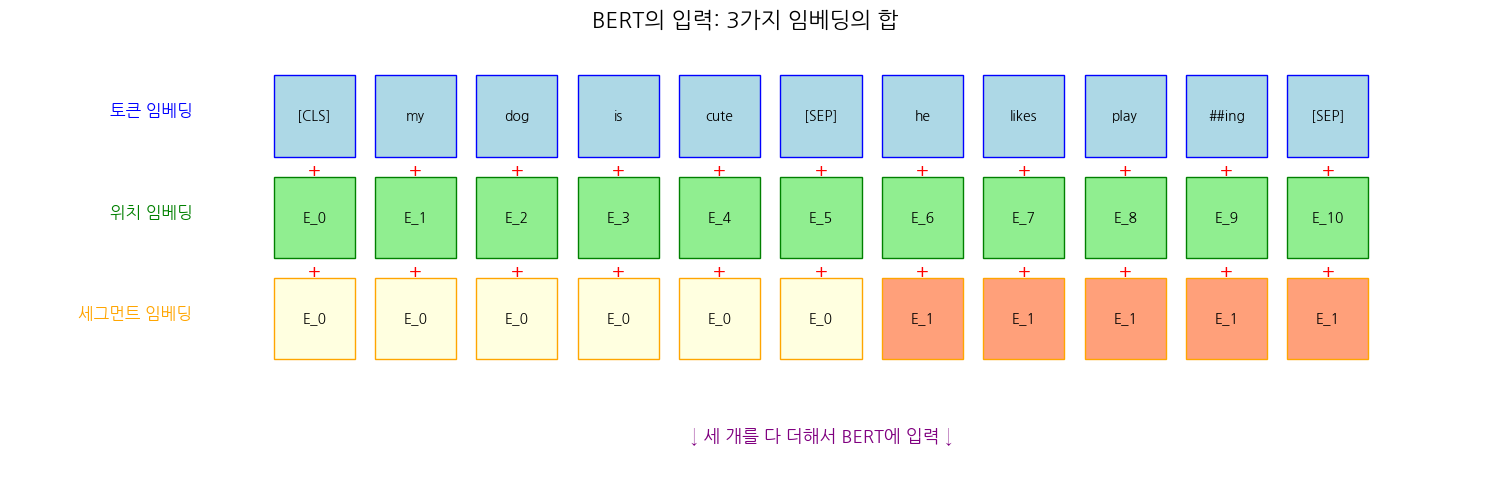


💡 토큰 임베딩 + 위치 임베딩 + 세그먼트 임베딩 = BERT 입력


In [9]:
# 🎨 BERT 입력 구조 시각화
fig, ax = plt.subplots(figsize=(15, 6))

tokens = ['[CLS]', 'my', 'dog', 'is', 'cute', '[SEP]', 'he', 'likes', 'play', '##ing', '[SEP]']
positions = list(range(len(tokens)))
segments = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

n = len(tokens)
x_positions = np.arange(n)

# 토큰 임베딩 (파란색)
for i, t in enumerate(tokens):
    ax.add_patch(plt.Rectangle((i - 0.4, 2.5), 0.8, 0.8,
                                facecolor='lightblue', edgecolor='blue'))
    ax.text(i, 2.9, t, ha='center', va='center', fontsize=10, fontweight='bold')

# 위치 임베딩 (초록색)
for i, p in enumerate(positions):
    ax.add_patch(plt.Rectangle((i - 0.4, 1.5), 0.8, 0.8,
                                facecolor='lightgreen', edgecolor='green'))
    ax.text(i, 1.9, f'E_{p}', ha='center', va='center', fontsize=10)

# 세그먼트 임베딩 (주황색)
for i, s in enumerate(segments):
    color = 'lightyellow' if s == 0 else 'lightsalmon'
    ax.add_patch(plt.Rectangle((i - 0.4, 0.5), 0.8, 0.8,
                                facecolor=color, edgecolor='orange'))
    ax.text(i, 0.9, f'E_{s}', ha='center', va='center', fontsize=10)

# 더하기 기호
for i in range(n):
    ax.text(i, 2.3, '+', ha='center', fontsize=14, fontweight='bold', color='red')
    ax.text(i, 1.3, '+', ha='center', fontsize=14, fontweight='bold', color='red')

# 레이블
ax.text(-1.2, 2.9, '토큰 임베딩', ha='right', fontsize=12, fontweight='bold', color='blue')
ax.text(-1.2, 1.9, '위치 임베딩', ha='right', fontsize=12, fontweight='bold', color='green')
ax.text(-1.2, 0.9, '세그먼트 임베딩', ha='right', fontsize=12, fontweight='bold', color='orange')

# 결과
ax.text(n/2 - 0.5, -0.3, '↓ 세 개를 다 더해서 BERT에 입력 ↓', ha='center', fontsize=13,
        fontweight='bold', color='purple')

ax.set_xlim(-3, n + 0.5)
ax.set_ylim(-0.7, 3.7)
ax.set_aspect('equal')
ax.axis('off')
plt.title('BERT의 입력: 3가지 임베딩의 합', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 토큰 임베딩 + 위치 임베딩 + 세그먼트 임베딩 = BERT 입력")

In [10]:
# 🔬 실제로 두 문장을 BERT에 넣어보기
sentence_a = "My dog is cute."
sentence_b = "He likes playing."

# 두 문장을 함께 토큰화
encoded = tokenizer(sentence_a, sentence_b, return_tensors='pt')

print("📝 문장 A:", sentence_a)
print("📝 문장 B:", sentence_b)
print()
print("🔢 input_ids (단어 ID):")
print(encoded['input_ids'][0].tolist())
print()
print("🏷️ token_type_ids (세그먼트, 어느 문장인지):")
print(encoded['token_type_ids'][0].tolist())
print("→ 0은 문장 A, 1은 문장 B 소속")
print()
print("👁️ attention_mask (실제 단어 vs 패딩):")
print(encoded['attention_mask'][0].tolist())
print()

# 토큰으로 다시 변환해서 보기
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
print("🧩 실제 토큰들:")
for tok, tid, seg in zip(tokens, encoded['input_ids'][0].tolist(),
                          encoded['token_type_ids'][0].tolist()):
    print(f"   {tok:12s} (ID: {tid:5d}, 세그먼트: {seg})")

📝 문장 A: My dog is cute.
📝 문장 B: He likes playing.

🔢 input_ids (단어 ID):
[101, 2026, 3899, 2003, 10140, 1012, 102, 2002, 7777, 2652, 1012, 102]

🏷️ token_type_ids (세그먼트, 어느 문장인지):
[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
→ 0은 문장 A, 1은 문장 B 소속

👁️ attention_mask (실제 단어 vs 패딩):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

🧩 실제 토큰들:
   [CLS]        (ID:   101, 세그먼트: 0)
   my           (ID:  2026, 세그먼트: 0)
   dog          (ID:  3899, 세그먼트: 0)
   is           (ID:  2003, 세그먼트: 0)
   cute         (ID: 10140, 세그먼트: 0)
   .            (ID:  1012, 세그먼트: 0)
   [SEP]        (ID:   102, 세그먼트: 0)
   he           (ID:  2002, 세그먼트: 1)
   likes        (ID:  7777, 세그먼트: 1)
   playing      (ID:  2652, 세그먼트: 1)
   .            (ID:  1012, 세그먼트: 1)
   [SEP]        (ID:   102, 세그먼트: 1)


## 🧠 퀴즈 #2

두 문장 "I love AI." 와 "It's amazing." 을 BERT에 함께 넣었을 때, 다음 중 세그먼트 ID가 **다른** 토큰의 조합은?

- A) `[CLS]` 와 `I`
- B) `love` 와 `[SEP]` (첫 번째)
- C) `[SEP]` (첫 번째) 와 `It`
- D) `amazing` 와 `[SEP]` (두 번째)

<details>
<summary>👉 정답 보기</summary>

**C) `[SEP]` (첫 번째) 와 `It`**
- 첫 번째 `[SEP]`까지는 세그먼트 0 (문장 A)
- `It` 부터는 세그먼트 1 (문장 B)

</details>

---
# 5️⃣ MLM (Masked Language Model) - 빈칸 채우기 학습

## 🎭 MLM이 뭔가요?

> **"문장에 빈칸을 만들고, BERT가 빈칸의 단어를 맞히게 하는 학습법"**

비유: **수능 영어 빈칸 채우기 문제** 풀기!

## 📋 학습 방법

### Step 1: 문장의 15% 단어를 마스킹
원문: "The cat sat on the mat"
마스킹: "The cat **[MASK]** on the mat"

### Step 2: BERT가 빈칸의 단어 맞히기
BERT의 답: "sat" ✅

### Step 3: 정답과 비교해서 학습
틀렸으면 → 다음엔 더 잘 맞히도록 모델 수정

## 🎯 왜 효과적인가?

- 빈칸을 맞히려면 **앞뒤 문맥을 다 봐야** 해요
- 자연스럽게 **양방향 이해** 능력이 길러집니다
- 정답이 이미 있으니 **자동으로 채점** 가능 → 데이터 무한 생성!

## 🔀 마스킹 트릭 (왜 [MASK]만 쓰지 않을까?)

15% 대상 단어 중:
- **80%** → `[MASK]`로 치환
- **10%** → 랜덤한 다른 단어로 치환
- **10%** → 그대로 유지

> 💡 **이유**: 실제 사용 시엔 `[MASK]`가 안 나오는데, 학습 때 너무 의존하면 안 되니까 다양하게 섞어요!

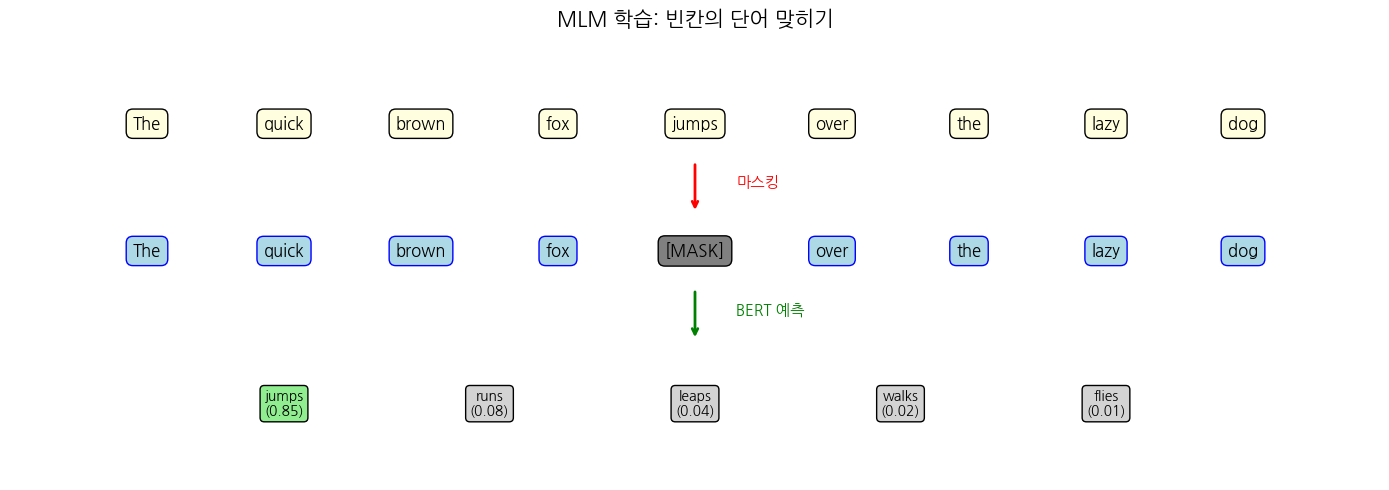


💡 BERT는 'jumps'를 가장 높은 확률로 예측했어요!
💡 정답과 비교해서 모델이 점점 똑똑해집니다.


In [11]:
# 🎨 MLM 학습 과정 시각화
fig, ax = plt.subplots(figsize=(14, 5))

original = ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
masked_idx = 4  # 'jumps'를 마스킹

# 원문 (위)
for i, w in enumerate(original):
    ax.text(i, 2.5, w, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black'))

# 화살표
ax.annotate('', xy=(masked_idx, 1.8), xytext=(masked_idx, 2.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(masked_idx + 0.3, 2.0, '마스킹', color='red', fontsize=11)

# 마스킹된 문장 (가운데)
for i, w in enumerate(original):
    if i == masked_idx:
        ax.text(i, 1.5, '[MASK]', ha='center', va='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='gray', edgecolor='black'))
    else:
        ax.text(i, 1.5, w, ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', edgecolor='blue'))

# 화살표
ax.annotate('', xy=(masked_idx, 0.8), xytext=(masked_idx, 1.2),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(masked_idx + 0.3, 1.0, 'BERT 예측', color='green', fontsize=11)

# BERT의 예측 (아래)
predictions = [('jumps', 0.85), ('runs', 0.08), ('leaps', 0.04), ('walks', 0.02), ('flies', 0.01)]
for j, (pred, prob) in enumerate(predictions):
    color = 'lightgreen' if j == 0 else 'lightgray'
    ax.text(masked_idx + j*1.5 - 3, 0.3, f"{pred}\n({prob:.2f})",
            ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))

ax.set_xlim(-1, len(original))
ax.set_ylim(-0.3, 3.2)
ax.set_title('MLM 학습: 빈칸의 단어 맞히기', fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n💡 BERT는 'jumps'를 가장 높은 확률로 예측했어요!")
print("💡 정답과 비교해서 모델이 점점 똑똑해집니다.")

In [12]:
# 🎯 실제로 사전학습된 BERT로 빈칸 맞히기!
from transformers import pipeline

# fill-mask 파이프라인 (MLM 작업 자동화)
fill_mask = pipeline('fill-mask', model='bert-base-uncased')

# 문제 1
result = fill_mask("The capital of France is [MASK].")
print("🎯 문제: The capital of France is [MASK].")
print("📊 BERT의 예측 (상위 5개):")
for r in result[:5]:
    print(f"   {r['token_str']:15s} 확률: {r['score']:.4f}")
print()

# 문제 2
result = fill_mask("I love eating [MASK] for breakfast.")
print("🎯 문제: I love eating [MASK] for breakfast.")
print("📊 BERT의 예측 (상위 5개):")
for r in result[:5]:
    print(f"   {r['token_str']:15s} 확률: {r['score']:.4f}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🎯 문제: The capital of France is [MASK].
📊 BERT의 예측 (상위 5개):
   paris           확률: 0.4168
   lille           확률: 0.0714
   lyon            확률: 0.0634
   marseille       확률: 0.0444
   tours           확률: 0.0303

🎯 문제: I love eating [MASK] for breakfast.
📊 BERT의 예측 (상위 5개):
   it              확률: 0.0605
   something       확률: 0.0582
   pancakes        확률: 0.0513
   fish            확률: 0.0347
   them            확률: 0.0345


## 🎯 빈칸 채우기 실습 #2

여러분이 직접 문장을 만들어서 BERT에게 풀어보게 해봅시다!

> 🔍 **힌트**: `[MASK]` 토큰을 문장에 넣고 `fill_mask()`를 호출하세요.

In [13]:
# 🎯 실습 #2: 직접 문제 만들어보기
# TODO: 아래 문장에서 ____ 부분을 [MASK]로 채워서 BERT에게 풀게 해보세요
# 예: "Apple is a [MASK] company." (회사 분야 맞히기)

my_sentence = "Mir is a [MASK] cat."

# TODO: my_sentence를 fill_mask()에 넣어 결과를 받으세요
results = fill_mask(my_sentence)

print(f"🎯 문제: {my_sentence}")
print(f"📊 BERT의 답:")
for r in results[:3]:
    print(f"   {r['token_str']:15s} 확률: {r['score']:.4f}")

🎯 문제: Mir is a [MASK] cat.
📊 BERT의 답:
   domestic        확률: 0.1658
   black           확률: 0.0888
   large           확률: 0.0300


<details>
<summary>🔑 정답 보기</summary>

```python
my_sentence = "Apple is a [MASK] company."
results = fill_mask(my_sentence)
```

- `____` → `[MASK]` (대괄호와 함께)
- `fill_mask(my_sentence)` 호출
- 다른 예시도 시도해보세요:
  - `"The weather is [MASK] today."`
  - `"My favorite sport is [MASK]."`

</details>

---
# 6️⃣ NSP (Next Sentence Prediction) - 이어지는 문장 맞히기

## 🔗 NSP가 뭔가요?

> **"두 문장이 실제로 이어지는 문장인지 BERT가 판단하는 학습법"**

비유: **퍼즐 조각이 맞는지 판단**하기!

## 📋 학습 방법

### 두 문장 A, B를 BERT에 보여줌:
- **50%**: B가 A 다음에 실제로 오는 문장 → 정답: **IsNext** ✅
- **50%**: B가 랜덤한 다른 문장 → 정답: **NotNext** ❌

### 예시 1 (이어짐):
- A: "The man went to the store."
- B: "He bought a gallon of milk."
- 정답: **IsNext** ✅ (이어짐)

### 예시 2 (안 이어짐):
- A: "The man went to the store."
- B: "Penguins live in Antarctica."
- 정답: **NotNext** ❌ (안 이어짐)

## 🎯 왜 NSP가 필요한가?

- **문장 단위 관계**를 이해해야 하는 작업에 유용:
  - 질문-답변
  - 문장 유사도
  - 자연어 추론

## 🤔 NSP의 운명...

> ⚠️ **재미있는 사실**: 후속 연구에서 NSP가 별로 효과적이지 않다는 게 밝혀졌어요!
> RoBERTa 같은 후속 모델은 NSP를 빼버렸습니다.

하지만 BERT의 원래 학습 방식이니 알아두면 좋아요. 📖

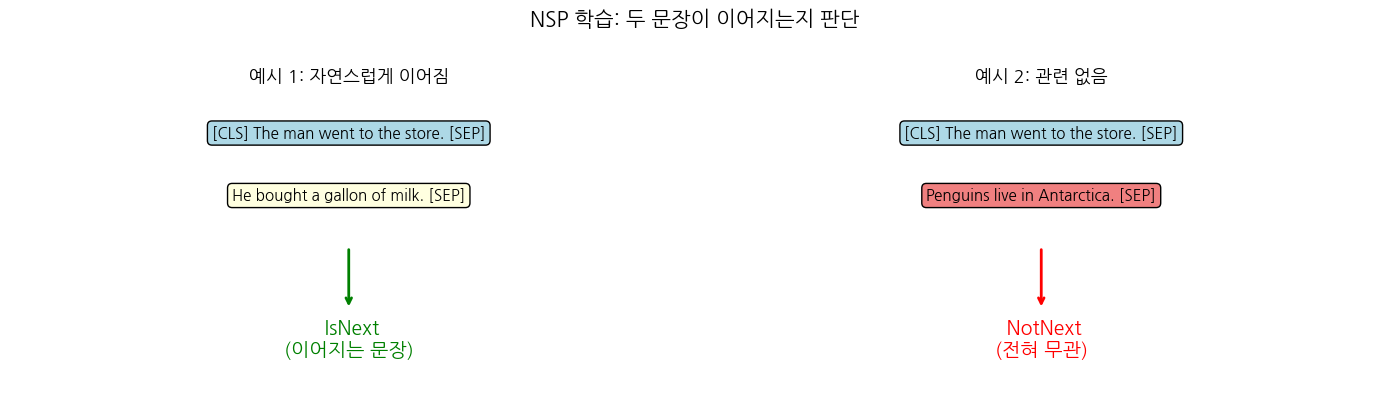

In [14]:
# 🎨 NSP 학습 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 예시 1: IsNext
ax1 = axes[0]
ax1.text(0.5, 0.85, '[CLS] The man went to the store. [SEP]',
         ha='center', fontsize=11, transform=ax1.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue'))
ax1.text(0.5, 0.65, 'He bought a gallon of milk. [SEP]',
         ha='center', fontsize=11, transform=ax1.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.annotate('', xy=(0.5, 0.3), xytext=(0.5, 0.5),
             xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax1.text(0.5, 0.15, ' IsNext\n(이어지는 문장)',
         ha='center', fontsize=14, fontweight='bold', color='green',
         transform=ax1.transAxes)
ax1.set_title('예시 1: 자연스럽게 이어짐', fontsize=13, fontweight='bold')
ax1.axis('off')

# 예시 2: NotNext
ax2 = axes[1]
ax2.text(0.5, 0.85, '[CLS] The man went to the store. [SEP]',
         ha='center', fontsize=11, transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue'))
ax2.text(0.5, 0.65, 'Penguins live in Antarctica. [SEP]',
         ha='center', fontsize=11, transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightcoral'))
ax2.annotate('', xy=(0.5, 0.3), xytext=(0.5, 0.5),
             xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax2.text(0.5, 0.15, ' NotNext\n(전혀 무관)',
         ha='center', fontsize=14, fontweight='bold', color='red',
         transform=ax2.transAxes)
ax2.set_title('예시 2: 관련 없음', fontsize=13, fontweight='bold')
ax2.axis('off')

plt.suptitle('NSP 학습: 두 문장이 이어지는지 판단', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 BERT가 답을 어떻게 내나요?

### `[CLS]` 토큰의 비밀

`[CLS]` 토큰은 **문장 전체의 요약 정보**를 담고 있어요!

비유: 반장이 우리 반 분위기를 대표해서 발표하는 것과 같아요. 📋

### MLM vs NSP 결과 출력 위치

| 학습 | 어디서 답을 보나? | 비유 |
|------|------------------|------|
| **MLM** | `[MASK]` 위치의 출력 | 빈칸 있는 곳 보기 |
| **NSP** | `[CLS]` 위치의 출력 | 반장 보고 받기 |

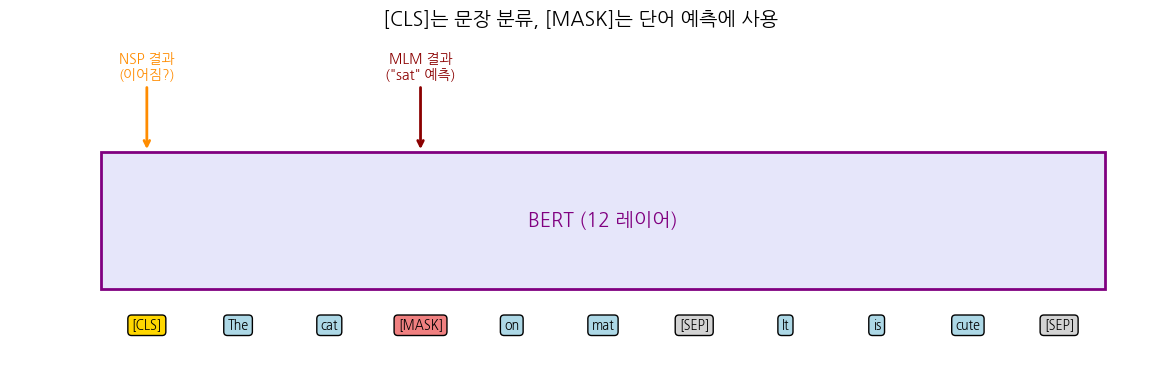


💡 [CLS]: 문장 전체를 대표 → 분류 작업 (NSP, 감정 분류 등)에 사용
💡 [MASK]: 빈칸 → 단어 예측 (MLM, 개체 태깅 등)에 사용


In [15]:
# 🎨 [CLS]와 [MASK]의 역할 시각화
fig, ax = plt.subplots(figsize=(14, 4))

tokens = ['[CLS]', 'The', 'cat', '[MASK]', 'on', 'mat', '[SEP]', 'It', 'is', 'cute', '[SEP]']
n = len(tokens)

# BERT 박스
ax.add_patch(plt.Rectangle((-0.5, 0.5), n, 1.5,
                            facecolor='lavender', edgecolor='purple', linewidth=2))
ax.text(n/2 - 0.5, 1.25, 'BERT (12 레이어)', ha='center', va='center',
        fontsize=14, fontweight='bold', color='purple')

# 입력 토큰
for i, t in enumerate(tokens):
    if t == '[CLS]':
        color = 'gold'
    elif t == '[MASK]':
        color = 'lightcoral'
    elif t == '[SEP]':
        color = 'lightgray'
    else:
        color = 'lightblue'
    ax.text(i, 0.1, t, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))

# 출력 표시
ax.annotate('NSP 결과\n(이어짐?)', xy=(0, 2.0), xytext=(0, 2.8),
            ha='center', fontsize=10, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2))
ax.annotate('MLM 결과\n("sat" 예측)', xy=(3, 2.0), xytext=(3, 2.8),
            ha='center', fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

ax.set_xlim(-1.5, n)
ax.set_ylim(-0.5, 3.3)
ax.set_aspect('equal')
ax.axis('off')
plt.title('[CLS]는 문장 분류, [MASK]는 단어 예측에 사용', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 [CLS]: 문장 전체를 대표 → 분류 작업 (NSP, 감정 분류 등)에 사용")
print("💡 [MASK]: 빈칸 → 단어 예측 (MLM, 개체 태깅 등)에 사용")

### ✅ 체크포인트 3

지금까지 배운 것:
- BERT 입력 = **토큰 + 위치 + 세그먼트** 임베딩의 합
- **MLM**: 빈칸 채우기로 양방향 이해 학습
- **NSP**: 두 문장이 이어지는지 판단
- **[CLS]** 토큰 = 문장 전체 요약
- **[MASK]** 토큰 = 빈칸 위치

다음은 드디어 **실제 BERT 모델을 다뤄보는** 단계입니다! 🚀

---
# 7️⃣ 파인튜닝이란?

## 🎯 파인튜닝 = "추가 직무 교육"

> **"이미 똑똑한 BERT에게 특정 작업을 가르치는 단계"**

## 🏫 비유: 대학 졸업생의 회사 입사

| 단계 | 비유 | BERT |
|------|------|------|
| 1단계 | 4년 대학 교양 교육 | **사전학습** (수십억 단어) |
| 2단계 | 회사 입사 후 직무 교육 | **파인튜닝** (수천~수만 예시) |

> 💡 사전학습된 BERT는 이미 **언어 자체**를 잘 이해해요.
> 파인튜닝은 그 위에 **"우리가 원하는 작업"을 추가**로 가르치는 거예요!

## 🛠️ 파인튜닝 작업 종류

BERT는 다양한 작업에 사용할 수 있어요:

### 📊 4가지 대표 작업 패턴

| 작업 유형 | 입력 | 출력 | 어디 보나? | 예시 |
|----------|------|------|----------|------|
| **문장 분류** | 문장 1개 | 카테고리 | `[CLS]` | 감정 분류 |
| **문장 쌍 분류** | 문장 2개 | 카테고리/유사도 | `[CLS]` | 문장 비교 |
| **토큰 분류** | 문장 1개 | 각 토큰별 라벨 | 각 토큰 | 개체 태깅 (NER) |
| **질문 답변** | 질문+지문 | 답의 위치 | 각 토큰 | QA |

## 🎨 시각화로 이해하기

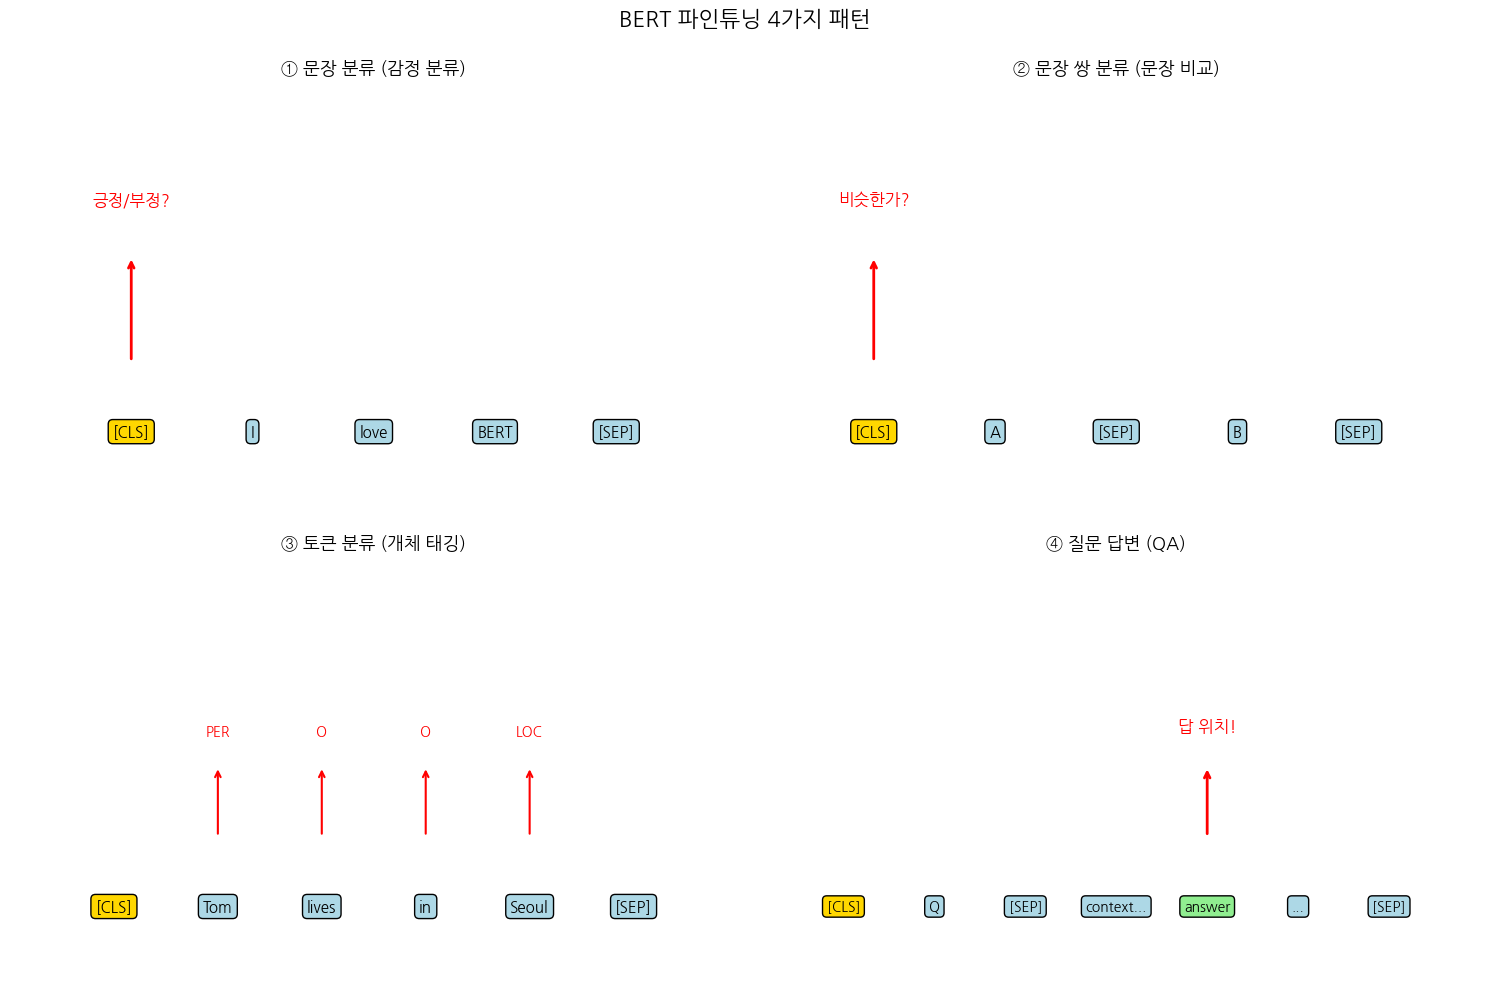

In [16]:
# 🎨 4가지 파인튜닝 패턴 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 문장 분류
ax = axes[0, 0]
tokens1 = ['[CLS]', 'I', 'love', 'BERT', '[SEP]']
for i, t in enumerate(tokens1):
    color = 'gold' if t == '[CLS]' else 'lightblue'
    ax.text(i, 0.5, t, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))
ax.annotate('', xy=(0, 1.5), xytext=(0, 0.9),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0, 1.8, '긍정/부정?', ha='center', fontsize=12, fontweight='bold', color='red')
ax.set_title('① 문장 분류 (감정 분류)', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 5); ax.set_ylim(0, 2.5); ax.axis('off')

# 2. 문장 쌍 분류
ax = axes[0, 1]
tokens2 = ['[CLS]', 'A', '[SEP]', 'B', '[SEP]']
for i, t in enumerate(tokens2):
    color = 'gold' if t == '[CLS]' else 'lightblue'
    ax.text(i, 0.5, t, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))
ax.annotate('', xy=(0, 1.5), xytext=(0, 0.9),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0, 1.8, '비슷한가?', ha='center', fontsize=12, fontweight='bold', color='red')
ax.set_title('② 문장 쌍 분류 (문장 비교)', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 5); ax.set_ylim(0, 2.5); ax.axis('off')

# 3. 토큰 분류
ax = axes[1, 0]
tokens3 = ['[CLS]', 'Tom', 'lives', 'in', 'Seoul', '[SEP]']
labels = ['', 'PER', 'O', 'O', 'LOC', '']
for i, (t, l) in enumerate(zip(tokens3, labels)):
    color = 'gold' if t == '[CLS]' else 'lightblue'
    ax.text(i, 0.5, t, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))
    if l:
        ax.text(i, 1.5, l, ha='center', va='center', fontsize=10, fontweight='bold', color='red')
        ax.annotate('', xy=(i, 1.3), xytext=(i, 0.9),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_title('③ 토큰 분류 (개체 태깅)', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 6); ax.set_ylim(0, 2.5); ax.axis('off')

# 4. QA
ax = axes[1, 1]
tokens4 = ['[CLS]', 'Q', '[SEP]', 'context...', 'answer', '...', '[SEP]']
positions_x = [0, 1, 2, 3, 4, 5, 6]
for i, t in enumerate(tokens4):
    color = 'gold' if t == '[CLS]' else ('lightgreen' if t == 'answer' else 'lightblue')
    ax.text(positions_x[i], 0.5, t, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))
ax.text(4, 1.5, '답 위치!', ha='center', fontsize=12, fontweight='bold', color='red')
ax.annotate('', xy=(4, 1.3), xytext=(4, 0.9),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_title('④ 질문 답변 (QA)', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 7); ax.set_ylim(0, 2.5); ax.axis('off')

plt.suptitle('BERT 파인튜닝 4가지 패턴', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## 🧠 퀴즈 #3

"이 영화는 정말 재미있었어요!" 라는 문장이 긍정인지 부정인지 판단하는 작업은 어떤 패턴인가요?

- A) 문장 분류 (`[CLS]` 사용)
- B) 토큰 분류 (각 토큰 사용)
- C) 질문 답변 (위치 찾기)
- D) 문장 생성

<details>
<summary>👉 정답 보기</summary>

**A) 문장 분류 (`[CLS]` 사용)**
- 문장 1개의 전체 의미를 보고 긍정/부정을 결정
- `[CLS]` 토큰 출력에 분류 레이어를 추가하여 학습

</details>

---
# 8️⃣ 실습 1: 감정 분류 (Sentiment Classification) 😊😢

## 🎯 목표

> **"리뷰 문장을 보고 긍정인지 부정인지 판별"**

## 🏗️ 모델 구조

```
입력 문장 → BERT → [CLS] 출력 → 분류기(Linear) → 긍정/부정
```

## 📚 데이터: 영화 리뷰

작은 예제 데이터셋으로 실습합니다.

| 문장 | 라벨 |
|------|------|
| "I loved this movie!" | 1 (긍정) |
| "Terrible waste of time." | 0 (부정) |
| ... | ... |

## 🚀 두 가지 방법

### 방법 A: 사전학습 모델 바로 사용 (Zero-shot)
- 이미 감정 분류로 파인튜닝된 모델 사용
- 별도 학습 없이 바로 예측

### 방법 B: 직접 파인튜닝
- 처음부터 BERT를 우리 데이터에 학습
- 시간이 좀 걸리지만 원리 이해에 좋음

먼저 방법 A부터 가볍게 시도해봅시다!

In [17]:
# 🎯 방법 A: 이미 학습된 감정 분류 모델 사용
from transformers import pipeline

# 감정 분석 파이프라인
sentiment_pipe = pipeline('sentiment-analysis')

# 테스트 문장들
test_sentences = [
    "I absolutely loved this movie! Best film of the year.",
    "Worst experience ever. Total waste of money.",
    "The acting was decent but the plot was confusing.",
    "Highly recommend! Brilliant performances throughout.",
    "I fell asleep halfway through. So boring.",
]

print("🎬 영화 리뷰 감정 분석")
print("=" * 60)
for sent in test_sentences:
    result = sentiment_pipe(sent)[0]
    emoji = "😊" if result['label'] == 'POSITIVE' else "😢"
    print(f"{emoji} [{result['label']:8s}] ({result['score']:.2%}) {sent}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

🎬 영화 리뷰 감정 분석
😊 [POSITIVE] (99.99%) I absolutely loved this movie! Best film of the year.
😢 [NEGATIVE] (99.98%) Worst experience ever. Total waste of money.
😢 [NEGATIVE] (99.57%) The acting was decent but the plot was confusing.
😊 [POSITIVE] (99.99%) Highly recommend! Brilliant performances throughout.
😢 [NEGATIVE] (99.98%) I fell asleep halfway through. So boring.


## 🔬 방법 B: 직접 파인튜닝하기

### 작업 흐름

1. 작은 데이터셋 준비 (긍정/부정 리뷰)
2. BERT 토크나이저로 인코딩
3. BERT + 분류 헤드 모델 정의
4. 학습 (몇 에포크만)
5. 테스트

In [31]:
# 📦 1단계: 데이터 준비
# 간단한 영화 리뷰 데이터 (실습용으로 작게)
train_texts = [
    # 긍정 리뷰 (라벨 1)
    "I loved this movie, it was fantastic!",
    "Amazing performance by the lead actor.",
    "Brilliant film, highly recommend it.",
    "This is the best movie I've seen this year.",
    "Wonderful story and great visuals.",
    "An absolute masterpiece of cinema.",
    "Beautiful direction and compelling characters.",
    "I was on the edge of my seat the whole time.",
    "Heartwarming and inspiring story.",
    "Perfect blend of humor and drama.",
    # 부정 리뷰 (라벨 0)
    "This movie was terrible, I want my money back.",
    "Boring and predictable plot.",
    "The acting was awful and unconvincing.",
    "Worst film I've watched in years.",
    "Total waste of time, do not recommend.",
    "Disappointing and poorly executed.",
    "I fell asleep halfway through.",
    "The story made no sense at all.",
    "Painfully slow and uninteresting.",
    "Awful dialogue and weak characters.",
]
train_labels = [1]*10 + [0]*10

test_texts = [
    "What a fantastic experience, loved every minute!",
    "Don't bother watching, it's really bad.",
]
test_labels = [1, 0]

print(f"📊 학습 데이터: {len(train_texts)}개")
print(f"📊 테스트 데이터: {len(test_texts)}개")
print(f"   긍정: {sum(train_labels)}개, 부정: {len(train_labels) - sum(train_labels)}개")

📊 학습 데이터: 20개
📊 테스트 데이터: 2개
   긍정: 10개, 부정: 10개


In [32]:
# 🔧 2단계: 토크나이저로 데이터 변환
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 학습 데이터 인코딩
train_encodings = tokenizer(train_texts, truncation=True, padding=True,
                             max_length=32, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True,
                            max_length=32, return_tensors='pt')

print("📦 인코딩 결과 예시 (첫 번째 문장):")
print(f"   원문: {train_texts[0]}")
print(f"   토큰: {tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][0])}")
print(f"   shape: {train_encodings['input_ids'].shape}")
print(f"   ↑ (문장 수, 최대 토큰 길이)")

📦 인코딩 결과 예시 (첫 번째 문장):
   원문: I loved this movie, it was fantastic!
   토큰: ['[CLS]', 'i', 'loved', 'this', 'movie', ',', 'it', 'was', 'fantastic', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
   shape: torch.Size([20, 14])
   ↑ (문장 수, 최대 토큰 길이)


In [33]:
# 🏗️ 3단계: BERT + 분류 헤드 모델 정의
import torch
import torch.nn as nn
from transformers import BertModel

class BERTSentimentClassifier(nn.Module):
    """
    BERT 위에 분류 헤드를 얹은 모델

    구조:
        BERT → [CLS] 출력 (768차원) → Dropout → Linear → 2개 클래스
    """
    def __init__(self, num_classes=2):
        super().__init__()
        # 사전학습된 BERT 로드
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        # 드롭아웃 (과적합 방지)
        self.dropout = nn.Dropout(0.3)
        # 분류 레이어 (768 → 2)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT를 통과시킴
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] 토큰의 출력만 사용 (pooler_output)
        cls_output = outputs.pooler_output  # (batch, 768)
        # 드롭아웃 적용
        cls_output = self.dropout(cls_output)
        # 분류 결과 (batch, 2)
        logits = self.classifier(cls_output)
        return logits

# 모델 생성
model = BERTSentimentClassifier(num_classes=2).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"🏗️ 모델 생성 완료!")
print(f"📊 총 파라미터 수: {total_params:,}개")
print(f"   (대부분 BERT의 1억 1천만 파라미터)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🏗️ 모델 생성 완료!
📊 총 파라미터 수: 109,483,778개
   (대부분 BERT의 1억 1천만 파라미터)


In [34]:
# 🎓 4단계: 학습
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

# Dataset과 DataLoader 만들기
train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(train_labels)
)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 옵티마이저와 손실 함수
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# 학습 루프
print("🚀 학습 시작...")
losses = []
model.train()
EPOCHS = 3

for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch_idx, (input_ids, attn_mask, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels = labels.to(device)

        # Forward
        logits = model(input_ids, attn_mask)
        loss = criterion(logits, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        losses.append(loss.item())

    avg_loss = epoch_loss / len(train_loader)
    print(f"   Epoch {epoch+1}/{EPOCHS}, 평균 손실: {avg_loss:.4f}")

print("✅ 학습 완료!")

🚀 학습 시작...
   Epoch 1/3, 평균 손실: 0.6695
   Epoch 2/3, 평균 손실: 0.7244
   Epoch 3/3, 평균 손실: 0.6558
✅ 학습 완료!


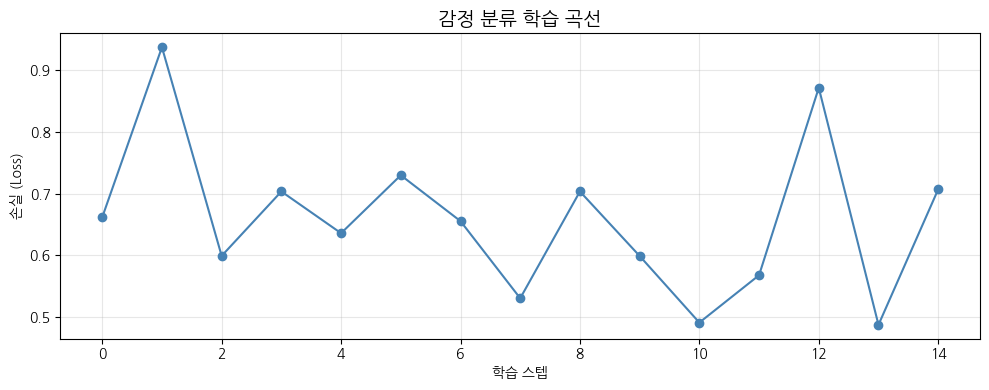


💡 손실이 줄어들고 있다면 학습이 잘 되고 있는 거예요!


In [22]:
# 📊 학습 곡선 시각화
plt.figure(figsize=(10, 4))
plt.plot(losses, marker='o', linestyle='-', color='steelblue')
plt.xlabel('학습 스텝')
plt.ylabel('손실 (Loss)')
plt.title('감정 분류 학습 곡선', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 손실이 줄어들고 있다면 학습이 잘 되고 있는 거예요!")

In [23]:
# 🧪 5단계: 테스트
model.eval()

print("🧪 새로운 문장으로 테스트")
print("=" * 60)

with torch.no_grad():
    input_ids = test_encodings['input_ids'].to(device)
    attn_mask = test_encodings['attention_mask'].to(device)

    logits = model(input_ids, attn_mask)
    probs = torch.softmax(logits, dim=-1)
    preds = torch.argmax(logits, dim=-1)

    for i, text in enumerate(test_texts):
        pred = preds[i].item()
        prob = probs[i][pred].item()
        actual = test_labels[i]
        emoji = "😊" if pred == 1 else "😢"
        label_str = "긍정" if pred == 1 else "부정"
        correct = "✅" if pred == actual else "❌"
        print(f"{correct} {emoji} 예측: {label_str} ({prob:.2%}) | 문장: {text}")

🧪 새로운 문장으로 테스트
✅ 😊 예측: 긍정 (54.83%) | 문장: What a fantastic experience, loved every minute!
✅ 😢 예측: 부정 (54.58%) | 문장: Don't bother watching, it's really bad.


## 🎯 빈칸 채우기 실습 #3

여러분의 문장을 직접 만들어서 학습한 모델로 감정을 분석해보세요!

> 🔍 **힌트**: 1) 문장을 `tokenizer()`로 인코딩, 2) `model()`로 예측, 3) `argmax`로 라벨 결정

In [24]:
# 🎯 실습 #3: 내 문장 감정 분석
my_sentences = [
    "This is the most amazing thing ever!",
    "I really hated every moment of it."
]

# TODO: 1. my_sentences를 tokenizer로 인코딩하세요 (padding=True, truncation=True, return_tensors='pt')
my_encodings = tokenizer(my_sentences, padding=True, truncation=True, return_tensors='pt')

# TODO: 2. 모델에 input_ids와 attention_mask를 전달하세요
model.eval()
with torch.no_grad():
    logits = model(my_encodings['input_ids'].to(device), my_encodings['attention_mask'].to(device))
    probs = torch.softmax(logits, dim=-1)
    # TODO: 3. argmax로 예측 라벨을 구하세요 (dim=-1)
    preds = torch.argmax(logits, dim=-1)

# 결과 출력
for i, sent in enumerate(my_sentences):
    label = "긍정 😊" if preds[i].item() == 1 else "부정 😢"
    print(f"[{label}] {sent}")

[긍정 😊] This is the most amazing thing ever!
[긍정 😊] I really hated every moment of it.


<details>
<summary>🔑 정답 보기</summary>

```python
my_encodings = tokenizer(my_sentences, padding=True, truncation=True, return_tensors='pt')

logits = model(my_encodings['input_ids'].to(device), my_encodings['attention_mask'].to(device))
preds = torch.argmax(logits, dim=-1)
```

- `tokenizer(my_sentences, ...)`: 문장 리스트 그대로 전달
- `attention_mask`: 실제 단어와 패딩을 구분하는 마스크
- `torch.argmax`: 가장 높은 확률의 클래스 선택

</details>

### ✅ 체크포인트 4 - 실습 1 완료!

🎉 첫 번째 BERT 실습 완료! 배운 것:
- 사전학습된 모델 그대로 사용하기 (pipeline)
- BERT + 분류 헤드 직접 만들기
- 학습 루프 작성하기
- `[CLS]` 토큰으로 문장 전체 분류하기

다음은 **개체 태깅 (NER)** 입니다! 🏷️

---
# 9️⃣ 실습 2: 개체 태깅 (NER) 🏷️

## 🎯 목표

> **"문장에서 사람·장소·회사 이름을 찾아내기"**

비유: **형광펜으로 중요한 단어에 표시**하기 🖍️

## 📚 NER이란?

**N**amed **E**ntity **R**ecognition = 개체명 인식

문장에서 다음과 같은 정보를 추출합니다:

| 태그 | 의미 | 예시 |
|------|------|------|
| **PER** | 사람 (Person) | Tom, 김철수 |
| **LOC** | 장소 (Location) | Seoul, Paris |
| **ORG** | 조직 (Organization) | Google, 삼성 |
| **MISC** | 기타 (Miscellaneous) | Olympics, iPhone |
| **O** | 개체 아님 (Outside) | the, is, and... |

## 📝 예시

**문장**: "Steve Jobs founded Apple in California."

| 토큰 | 태그 |
|------|------|
| Steve | B-PER |
| Jobs | I-PER |
| founded | O |
| Apple | B-ORG |
| in | O |
| California | B-LOC |

## 🔤 BIO 태깅 방식

| 접두사 | 의미 |
|--------|------|
| **B-** | 개체의 시작 (Begin) |
| **I-** | 개체의 중간/끝 (Inside) |
| **O** | 개체 아님 (Outside) |

> 💡 "Steve Jobs" 같은 **두 단어 이름**을 표현하기 위해 B-와 I-를 구분해요!

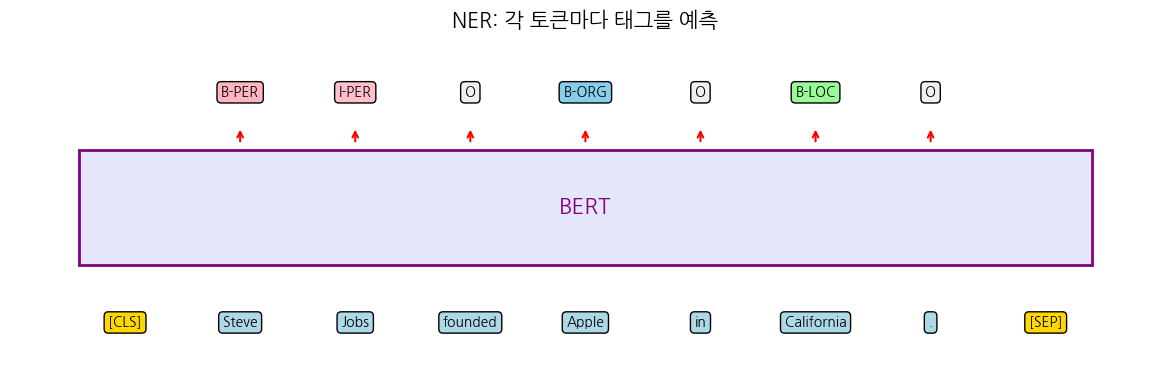


💡 NER은 '토큰 분류' 작업이에요. 각 토큰의 출력을 모두 사용합니다!


In [25]:
# 🎨 NER 구조 시각화
fig, ax = plt.subplots(figsize=(15, 4))

tokens = ['[CLS]', 'Steve', 'Jobs', 'founded', 'Apple', 'in', 'California', '.', '[SEP]']
tags = ['', 'B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC', 'O', '']
colors = {'B-PER': '#FFB6C1', 'I-PER': '#FFC0CB', 'B-ORG': '#87CEEB',
          'B-LOC': '#98FB98', 'O': '#F0F0F0'}

n = len(tokens)
# BERT 박스
ax.add_patch(plt.Rectangle((-0.4, 0.8), n-0.2, 1.0,
                            facecolor='lavender', edgecolor='purple', linewidth=2))
ax.text(n/2 - 0.5, 1.3, 'BERT', ha='center', va='center',
        fontsize=16, fontweight='bold', color='purple')

# 입력 토큰 (아래)
for i, t in enumerate(tokens):
    color = 'gold' if t in ['[CLS]', '[SEP]'] else 'lightblue'
    ax.text(i, 0.3, t, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))

# 출력 태그 (위)
for i, tag in enumerate(tags):
    if tag:
        c = colors.get(tag, '#F0F0F0')
        ax.text(i, 2.3, tag, ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=c, edgecolor='black'))
        ax.annotate('', xy=(i, 2.0), xytext=(i, 1.85),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlim(-1, n)
ax.set_ylim(-0.2, 2.8)
ax.set_aspect('equal')
ax.axis('off')
plt.title('NER: 각 토큰마다 태그를 예측', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 NER은 '토큰 분류' 작업이에요. 각 토큰의 출력을 모두 사용합니다!")

In [26]:
# 🎯 방법 A: 사전학습된 NER 모델 사용 (즉시 가능!)
from transformers import pipeline

# NER 파이프라인
ner_pipe = pipeline('ner', model='dslim/bert-base-NER', aggregation_strategy='simple')

test_sentences_ner = [
    "Steve Jobs founded Apple in California.",
    "Barack Obama was the 44th president of the United States.",
    "Elon Musk leads Tesla and SpaceX.",
    "Lionel Messi plays for Inter Miami in the United States.",
]

print("🏷️ 개체 태깅 결과")
print("=" * 70)
for sent in test_sentences_ner:
    print(f"\n📝 문장: {sent}")
    entities = ner_pipe(sent)
    if entities:
        for ent in entities:
            print(f"   🏷️ {ent['word']:20s} → {ent['entity_group']:6s} (확률: {ent['score']:.2%})")
    else:
        print("   (개체 없음)")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

🏷️ 개체 태깅 결과

📝 문장: Steve Jobs founded Apple in California.
   🏷️ Steve Jobs           → PER    (확률: 99.92%)
   🏷️ Apple                → ORG    (확률: 99.93%)
   🏷️ California           → LOC    (확률: 99.93%)

📝 문장: Barack Obama was the 44th president of the United States.
   🏷️ Barack Obama         → PER    (확률: 99.95%)
   🏷️ United States        → LOC    (확률: 99.95%)

📝 문장: Elon Musk leads Tesla and SpaceX.
   🏷️ El                   → PER    (확률: 66.38%)
   🏷️ ##on Musk            → PER    (확률: 80.65%)
   🏷️ Tesla                → ORG    (확률: 99.79%)
   🏷️ SpaceX               → ORG    (확률: 99.92%)

📝 문장: Lionel Messi plays for Inter Miami in the United States.
   🏷️ Lionel Messi         → PER    (확률: 99.94%)
   🏷️ Inter Miami          → ORG    (확률: 99.89%)
   🏷️ United States        → LOC    (확률: 99.94%)


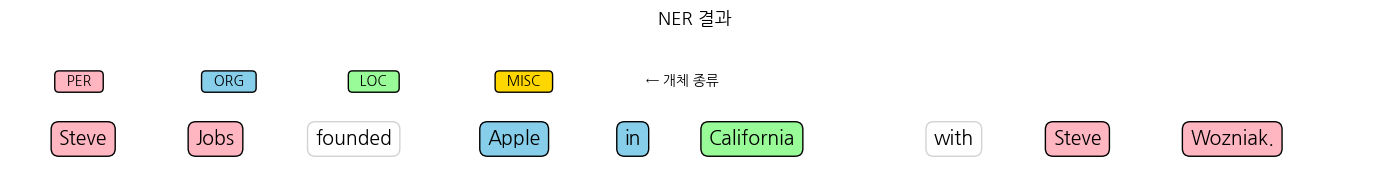

In [27]:
# 🎨 결과를 색깔로 시각화
def visualize_ner(sentence, entities):
    """개체 태깅 결과를 색깔로 시각화"""
    fig, ax = plt.subplots(figsize=(14, 2))

    colors = {'PER': '#FFB6C1', 'ORG': '#87CEEB', 'LOC': '#98FB98', 'MISC': '#FFD700'}

    # 문장을 단어로 쪼개기
    words = sentence.split()
    entity_words = {}
    for ent in entities:
        word = ent['word'].replace(' ##', '').replace('##', '')
        entity_words[word.lower()] = ent['entity_group']

    # 각 단어 표시
    x = 0
    for word in words:
        clean_word = word.strip('.,!?').lower()
        # 매칭 확인
        matched_type = None
        for ent_word, ent_type in entity_words.items():
            if ent_word.lower() in clean_word or clean_word in ent_word.lower():
                matched_type = ent_type
                break

        color = colors.get(matched_type, 'white')
        edge = 'black' if matched_type else 'lightgray'
        ax.text(x, 0.5, word, fontsize=14, ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor=edge))
        x += len(word) * 0.18 + 0.5

    # 범례
    legend_x = 0
    for tag, color in colors.items():
        ax.text(legend_x, 1.2, f"  {tag}  ", fontsize=10, ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color))
        legend_x += 1.5
    ax.text(legend_x, 1.2, '← 개체 종류', fontsize=10, va='center')

    ax.set_xlim(-0.5, x)
    ax.set_ylim(0, 1.8)
    ax.axis('off')
    plt.title(f'NER 결과', fontsize=13)
    plt.tight_layout()
    plt.show()

# 한 문장에 대해 시각화
sentence = "Steve Jobs founded Apple in California with Steve Wozniak."
entities = ner_pipe(sentence)
visualize_ner(sentence, entities)

## 🔬 방법 B: NER 모델 구조 이해하기

직접 학습하기엔 데이터 준비가 복잡하므로, 사전학습된 모델의 **구조와 동작**을 분석해봅시다.

In [28]:
# 🏗️ NER 모델의 내부 구조 살펴보기
from transformers import AutoTokenizer, AutoModelForTokenClassification

# 모델과 토크나이저 로드
ner_model_name = 'dslim/bert-base-NER'
tokenizer_ner = AutoTokenizer.from_pretrained(ner_model_name)
model_ner = AutoModelForTokenClassification.from_pretrained(ner_model_name)

print("🏗️ NER 모델 구조")
print("=" * 60)
print(f"📊 라벨 종류 ({model_ner.config.num_labels}개):")
for idx, label in model_ner.config.id2label.items():
    print(f"   {idx}: {label}")

print(f"\n💡 모델 출력 = 각 토큰마다 위 {model_ner.config.num_labels}개 라벨의 확률을 예측")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🏗️ NER 모델 구조
📊 라벨 종류 (9개):
   0: O
   1: B-MISC
   2: I-MISC
   3: B-PER
   4: I-PER
   5: B-ORG
   6: I-ORG
   7: B-LOC
   8: I-LOC

💡 모델 출력 = 각 토큰마다 위 9개 라벨의 확률을 예측


In [29]:
# 🔬 직접 토큰 단위로 예측해보기
sentence = "Sundar Pichai is the CEO of Google in California."

# 토큰화
inputs = tokenizer_ner(sentence, return_tensors='pt')
tokens = tokenizer_ner.convert_ids_to_tokens(inputs['input_ids'][0])

# 모델 예측
import torch
with torch.no_grad():
    outputs = model_ner(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)

# 결과 출력
print(f"📝 문장: {sentence}")
print()
print(f"{'토큰':<15s} {'예측 태그':<10s}")
print("-" * 30)
for token, pred_id in zip(tokens, predictions[0]):
    label = model_ner.config.id2label[pred_id.item()]
    # 개체가 아닌 토큰은 회색으로 표시
    marker = "🏷️" if label != 'O' else "  "
    print(f"{marker} {token:<13s} {label}")

📝 문장: Sundar Pichai is the CEO of Google in California.

토큰              예측 태그     
------------------------------
   [CLS]         O
🏷️ Sun           B-PER
🏷️ ##dar         I-PER
🏷️ Pi            I-PER
🏷️ ##cha         I-PER
🏷️ ##i           I-PER
   is            O
   the           O
   CEO           O
   of            O
🏷️ Google        B-ORG
   in            O
🏷️ California    B-LOC
   .             O
   [SEP]         O


## 🎯 빈칸 채우기 실습 #4

여러분의 문장으로 NER을 실행해보세요!

> 🔍 **힌트**: `ner_pipe()`에 문장을 그대로 넣으면 결과가 나옵니다.

In [35]:
# 🎯 실습 #4: 직접 NER 해보기
# 자유롭게 사람/장소/회사 이름이 들어간 문장을 만들어보세요
my_sentence = "Bill Gates founded Microsoft in Seattle."

# TODO: ner_pipe를 사용해 my_sentence의 개체를 추출하세요
my_entities = ner_pipe(my_sentence)

print(f"📝 분석할 문장: {my_sentence}")
print(f"\n🏷️ 발견한 개체들:")
for ent in my_entities:
    print(f"   • {ent['word']:20s} → {ent['entity_group']} (신뢰도: {ent['score']:.2%})")

📝 분석할 문장: Bill Gates founded Microsoft in Seattle.

🏷️ 발견한 개체들:
   • Bill Gates           → PER (신뢰도: 99.97%)
   • Microsoft            → ORG (신뢰도: 99.89%)
   • Seattle              → LOC (신뢰도: 99.90%)


<details>
<summary>🔑 정답 보기</summary>

```python
my_entities = ner_pipe(my_sentence)
```

- `ner_pipe()`는 문장을 받아 자동으로 개체를 추출합니다.
- 결과는 `[{'word': ..., 'entity_group': ..., 'score': ...}, ...]` 형태의 리스트
- 다른 문장도 시도해보세요: `"Albert Einstein was born in Germany."`

</details>

### ✅ 체크포인트 5 - 실습 2 완료!

🎉 NER 실습 완료! 배운 것:
- NER은 **토큰 단위 분류** 작업
- **BIO 태깅** 방식으로 다중 단어 개체 표현
- 사전학습 모델로 즉시 사용 가능

---
# 🔟 실습 3: 문장 비교 (STS) 📏

## 🎯 목표

> **"두 문장이 의미적으로 얼마나 비슷한지 측정"**

## 📚 STS란?

**S**emantic **T**extual **S**imilarity = 의미적 문장 유사도

### 예시
| 문장 A | 문장 B | 유사도 |
|--------|--------|--------|
| "고양이가 매트 위에 앉아있다" | "매트 위에 고양이가 앉아있다" | 95% (매우 비슷) |
| "고양이가 매트 위에 앉아있다" | "강아지가 공원에서 뛴다" | 10% (전혀 다름) |

## 🧮 어떻게 비교하나요?

### 방법: 각 문장을 **벡터(숫자 배열)**로 바꾼 뒤 거리 계산!

```
"좋은 영화입니다" → [0.3, 0.7, 0.1, ...] (768차원 벡터)
"훌륭한 영화에요" → [0.4, 0.6, 0.2, ...] (768차원 벡터)
              ↓
         코사인 유사도 = 0.92 (매우 비슷!)
```

## 🧭 코사인 유사도

비유: **두 화살표가 같은 방향을 가리키는 정도** 🧭

- **+1**: 완전히 같은 방향 (매우 비슷)
- **0**: 90도 (관련 없음)
- **-1**: 반대 방향 (정반대)

## 🛠️ Sentence-BERT (SBERT)

원래 BERT는 문장 벡터 추출에 비효율적이었어요.
**Sentence-BERT**는 문장 비교에 최적화된 BERT 버전입니다!

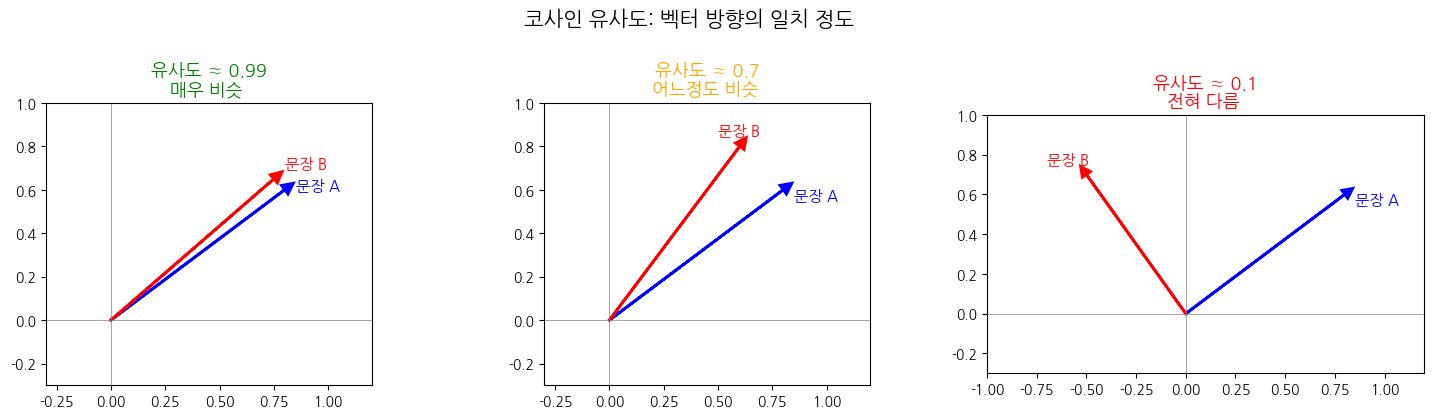

In [36]:
# 🎨 코사인 유사도 개념 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 케이스 1: 매우 비슷
ax = axes[0]
ax.arrow(0, 0, 0.8, 0.6, head_width=0.05, head_length=0.05, fc='blue', ec='blue', lw=2)
ax.arrow(0, 0, 0.75, 0.65, head_width=0.05, head_length=0.05, fc='red', ec='red', lw=2)
ax.text(0.85, 0.6, '문장 A', fontsize=11, color='blue')
ax.text(0.8, 0.7, '문장 B', fontsize=11, color='red')
ax.set_title('유사도 ≈ 0.99\n매우 비슷 ', fontsize=13, fontweight='bold', color='green')
ax.set_xlim(-0.3, 1.2); ax.set_ylim(-0.3, 1)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')

# 케이스 2: 보통
ax = axes[1]
ax.arrow(0, 0, 0.8, 0.6, head_width=0.05, head_length=0.05, fc='blue', ec='blue', lw=2)
ax.arrow(0, 0, 0.6, 0.8, head_width=0.05, head_length=0.05, fc='red', ec='red', lw=2)
ax.text(0.85, 0.55, '문장 A', fontsize=11, color='blue')
ax.text(0.5, 0.85, '문장 B', fontsize=11, color='red')
ax.set_title('유사도 ≈ 0.7\n어느정도 비슷 ', fontsize=13, fontweight='bold', color='orange')
ax.set_xlim(-0.3, 1.2); ax.set_ylim(-0.3, 1)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')

# 케이스 3: 전혀 다름
ax = axes[2]
ax.arrow(0, 0, 0.8, 0.6, head_width=0.05, head_length=0.05, fc='blue', ec='blue', lw=2)
ax.arrow(0, 0, -0.5, 0.7, head_width=0.05, head_length=0.05, fc='red', ec='red', lw=2)
ax.text(0.85, 0.55, '문장 A', fontsize=11, color='blue')
ax.text(-0.7, 0.75, '문장 B', fontsize=11, color='red')
ax.set_title('유사도 ≈ 0.1\n전혀 다름 ', fontsize=13, fontweight='bold', color='red')
ax.set_xlim(-1, 1.2); ax.set_ylim(-0.3, 1)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')

plt.suptitle('코사인 유사도: 벡터 방향의 일치 정도', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# 🎯 방법 A: BERT로 문장 벡터 추출 후 비교
import torch
from transformers import BertModel, BertTokenizer
import numpy as np

# BERT 모델 로드
tokenizer_sts = BertTokenizer.from_pretrained('bert-base-uncased')
model_sts = BertModel.from_pretrained('bert-base-uncased').to(device)
model_sts.eval()

def get_sentence_embedding(sentence):
    """문장을 768차원 벡터로 변환 ([CLS] 토큰 사용)"""
    inputs = tokenizer_sts(sentence, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model_sts(**inputs)
    # [CLS] 토큰의 출력을 문장 벡터로 사용
    return outputs.last_hidden_state[0, 0, :].cpu().numpy()

def cosine_similarity(v1, v2):
    """코사인 유사도 계산"""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# 테스트 문장 쌍
pairs = [
    ("The cat sat on the mat.", "A cat is sitting on a mat."),
    ("The cat sat on the mat.", "A dog runs in the park."),
    ("I love machine learning.", "Machine learning is amazing."),
    ("I love machine learning.", "I hate doing the laundry."),
    ("The weather is nice today.", "It's sunny outside today."),
]

print("📏 문장 유사도 비교")
print("=" * 80)
for s1, s2 in pairs:
    emb1 = get_sentence_embedding(s1)
    emb2 = get_sentence_embedding(s2)
    sim = cosine_similarity(emb1, emb2)

    # 시각적 표시
    bar = "█" * int(sim * 20)
    print(f"📝 A: {s1}")
    print(f"📝 B: {s2}")
    print(f"   유사도: {sim:.4f} {bar}")
    print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📏 문장 유사도 비교
📝 A: The cat sat on the mat.
📝 B: A cat is sitting on a mat.
   유사도: 0.8830 █████████████████

📝 A: The cat sat on the mat.
📝 B: A dog runs in the park.
   유사도: 0.8950 █████████████████

📝 A: I love machine learning.
📝 B: Machine learning is amazing.
   유사도: 0.9549 ███████████████████

📝 A: I love machine learning.
📝 B: I hate doing the laundry.
   유사도: 0.9341 ██████████████████

📝 A: The weather is nice today.
📝 B: It's sunny outside today.
   유사도: 0.9605 ███████████████████



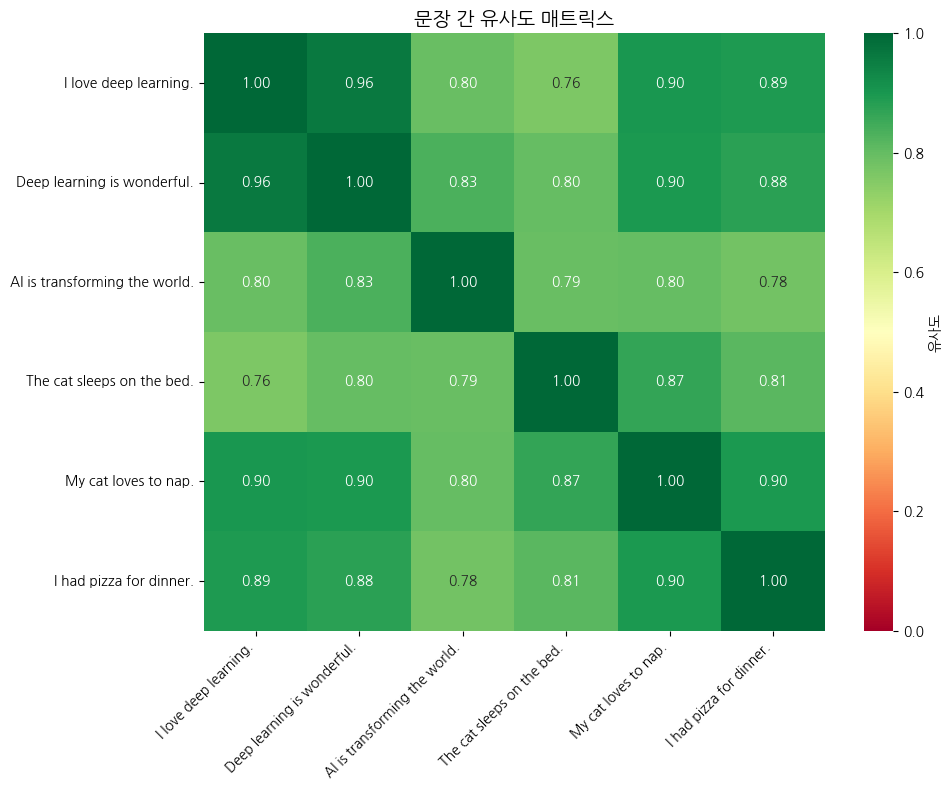


💡 비슷한 주제(AI/딥러닝, 고양이) 문장끼리 유사도가 높게 나와요!


In [38]:
# 🎨 유사도 매트릭스 시각화 (여러 문장 한꺼번에 비교)
sentences = [
    "I love deep learning.",
    "Deep learning is wonderful.",
    "AI is transforming the world.",
    "The cat sleeps on the bed.",
    "My cat loves to nap.",
    "I had pizza for dinner."
]

# 모든 문장의 임베딩 계산
embeddings = np.array([get_sentence_embedding(s) for s in sentences])

# 유사도 매트릭스
n = len(sentences)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))
short_labels = [s[:30] + ('...' if len(s) > 30 else '') for s in sentences]
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': '유사도'})
plt.title('문장 간 유사도 매트릭스', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 비슷한 주제(AI/딥러닝, 고양이) 문장끼리 유사도가 높게 나와요!")

## 🚀 더 좋은 방법: Sentence-BERT

원래 BERT의 `[CLS]` 토큰은 문장 벡터로 쓰기엔 한계가 있어요.
**Sentence-BERT (SBERT)**는 문장 비교에 특화되어 더 정확한 유사도를 제공합니다!

> 💡 SBERT는 문장 쌍으로 추가 학습된 BERT입니다.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

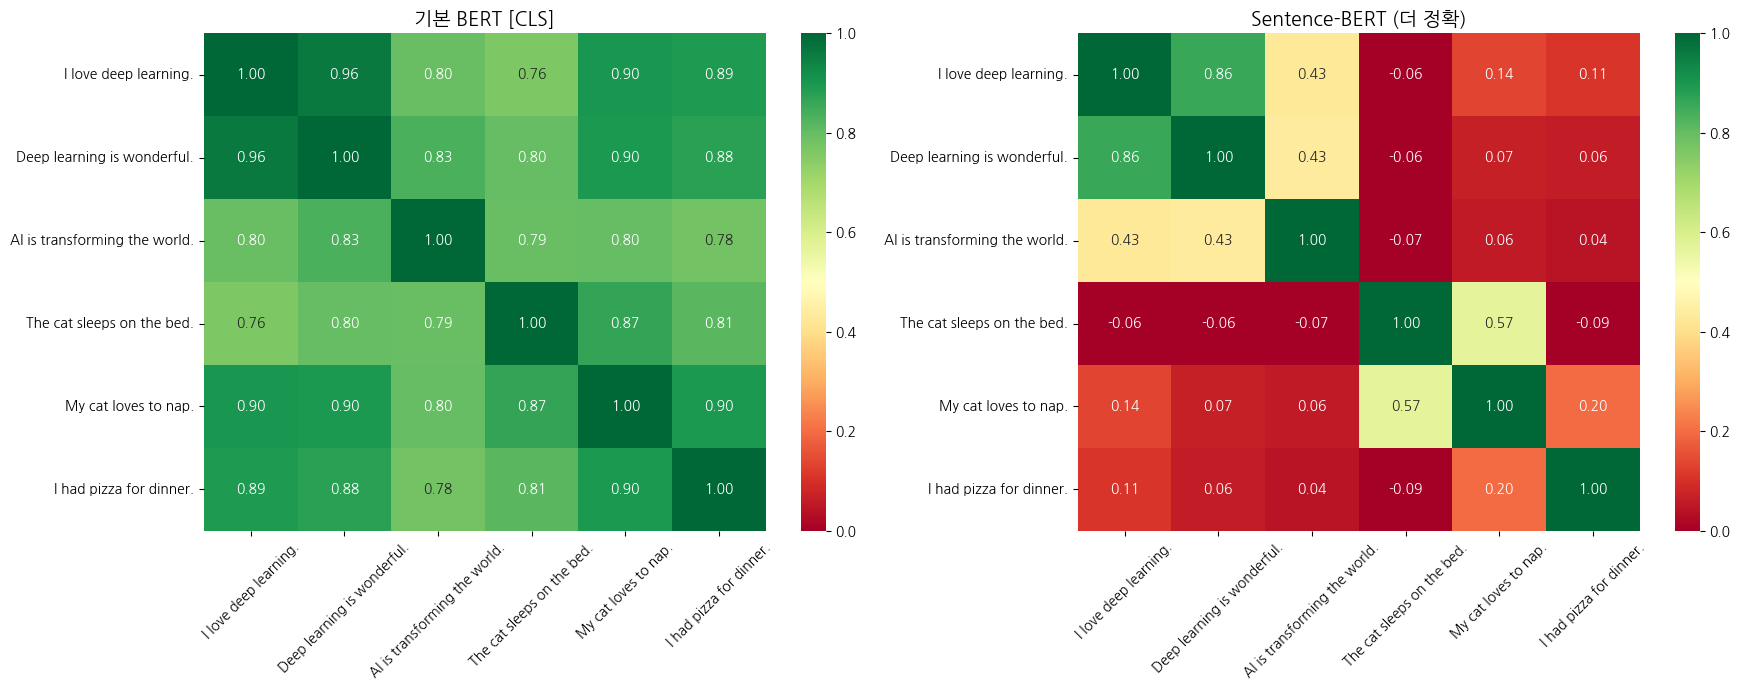


💡 SBERT는 유사한 문장은 더 높게, 다른 문장은 더 낮게 점수를 줍니다!


In [39]:
# 🚀 Sentence-BERT 사용하기 (더 정확한 문장 유사도)
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

# SBERT 모델 로드 (작고 빠른 모델)
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# 같은 문장들로 다시 비교
sbert_embeddings = sbert.encode(sentences)

# 유사도 매트릭스
sim_matrix_sbert = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix_sbert[i, j] = cosine_similarity(sbert_embeddings[i], sbert_embeddings[j])

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('기본 BERT [CLS]', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(sim_matrix_sbert, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Sentence-BERT (더 정확)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 SBERT는 유사한 문장은 더 높게, 다른 문장은 더 낮게 점수를 줍니다!")

## 🎯 빈칸 채우기 실습 #5

여러분만의 문장 쌍으로 유사도를 측정해보세요!

In [41]:
# 🎯 실습 #5: 직접 문장 유사도 측정
sentence1 = "Python is a great programming language."
sentence2 = "I enjoy coding in Python."
sentence3 = "Bananas are yellow fruits."

# TODO: 1. 세 문장을 SBERT로 임베딩하세요 (sbert.encode 사용)
embeddings = sbert.encode([sentence1, sentence2, sentence3])

# TODO: 2. sentence1과 sentence2의 유사도를 계산하세요
sim_1_2 = cosine_similarity(embeddings[0], embeddings[1])

# TODO: 3. sentence1과 sentence3의 유사도를 계산하세요
sim_1_3 = cosine_similarity(embeddings[0], embeddings[2])

print(f"📝 [1] {sentence1}")
print(f"📝 [2] {sentence2}")
print(f"📝 [3] {sentence3}")
print()
print(f"📏 [1] ↔ [2] 유사도: {sim_1_2:.4f}")
print(f"📏 [1] ↔ [3] 유사도: {sim_1_3:.4f}")
print()
print("💡 같은 주제 vs 다른 주제 비교를 확인해보세요!")

📝 [1] Python is a great programming language.
📝 [2] I enjoy coding in Python.
📝 [3] Bananas are yellow fruits.

📏 [1] ↔ [2] 유사도: 0.7757
📏 [1] ↔ [3] 유사도: -0.0921

💡 같은 주제 vs 다른 주제 비교를 확인해보세요!


<details>
<summary>🔑 정답 보기</summary>

```python
embeddings = sbert.encode([sentence1, sentence2, sentence3])
sim_1_2 = cosine_similarity(embeddings[0], embeddings[1])
sim_1_3 = cosine_similarity(embeddings[0], embeddings[2])
```

- `sbert.encode()`로 문장 리스트를 한 번에 임베딩
- 인덱스 `0, 1, 2`로 각 문장의 벡터 접근
- 같은 주제(Python) 문장끼리는 유사도가 높고, 바나나와는 낮을 거예요

</details>

### ✅ 체크포인트 6 - 실습 3 완료!

🎉 STS 실습 완료! 배운 것:
- 문장을 **벡터**로 변환해서 비교
- **코사인 유사도**로 비슷함 측정
- **Sentence-BERT**가 일반 BERT보다 문장 비교에 강함

다음은 마지막 실습 **질문 답변 (QA)** 입니다! ❓

---
# 1️⃣1️⃣ 실습 4: 질문 답변 (Question Answering) ❓

## 🎯 목표

> **"지문을 읽고 질문에 대한 답을 찾아내기"**

비유: **독해 시험 문제** 풀기 📖

## 📚 QA란?

지문(Context)과 질문(Question)을 주면, BERT가 **지문에서 답을 추출**합니다.

### 예시

**지문**:
> "Albert Einstein was a German-born theoretical physicist who developed the theory of relativity in 1915."

**질문**: "When did Einstein develop the theory of relativity?"

**답**: "1915"

## 🔧 동작 원리

BERT가 지문에서 **답의 시작 위치**와 **끝 위치**를 예측합니다!

```
지문 토큰들: [Einstein, was, born, in, Germany, in, 1879, ...]
                                                  ↑
                                            시작 = 끝 = "1879"
```

## 📊 구조

```
[CLS] 질문 [SEP] 지문 [SEP]
                ↓
              BERT
                ↓
  각 토큰마다 "답의 시작?" "답의 끝?" 예측
                ↓
       두 점수가 가장 높은 구간 = 답!
```

## 🎓 학습 데이터: SQuAD

**S**tanford **Qu**estion **A**nswering **D**ataset
- 약 10만 개의 (질문, 지문, 답) 쌍
- 위키피디아 기반

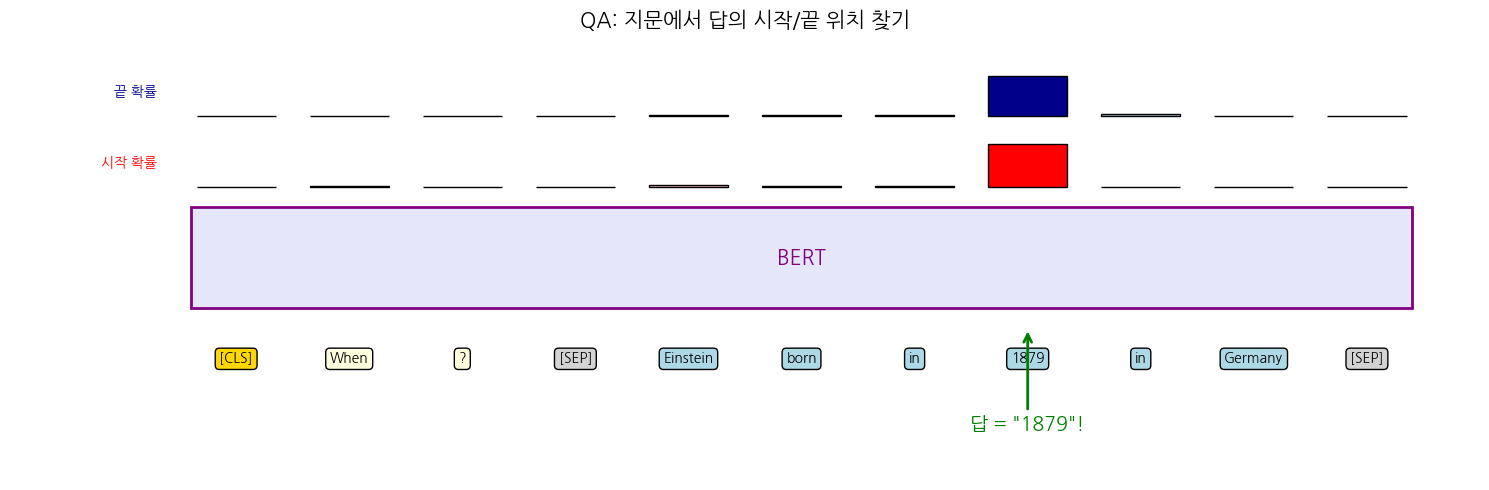


💡 BERT는 각 토큰에 대해 두 가지 점수를 출력해요:
    1) 답이 여기서 시작할 확률
    2) 답이 여기서 끝날 확률


In [42]:
# 🎨 QA 구조 시각화
fig, ax = plt.subplots(figsize=(15, 5))

tokens = ['[CLS]', 'When', '?', '[SEP]', 'Einstein', 'born', 'in', '1879', 'in', 'Germany', '[SEP]']
n = len(tokens)

# BERT 박스
ax.add_patch(plt.Rectangle((-0.4, 1.5), n-0.2, 1.0,
                            facecolor='lavender', edgecolor='purple', linewidth=2))
ax.text(n/2 - 0.5, 2.0, 'BERT', ha='center', va='center',
        fontsize=15, fontweight='bold', color='purple')

# 입력 토큰
for i, t in enumerate(tokens):
    if t == '[CLS]':
        color = 'gold'
    elif t == '[SEP]':
        color = 'lightgray'
    elif i < 3:  # 질문 부분
        color = 'lightyellow'
    else:  # 지문 부분
        color = 'lightblue'
    ax.text(i, 1.0, t, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color))

# 시작/끝 확률 (예시)
start_probs = [0.01, 0.02, 0.01, 0.01, 0.05, 0.03, 0.02, 0.85, 0.01, 0.01, 0.01]
end_probs   = [0.01, 0.01, 0.01, 0.01, 0.02, 0.03, 0.02, 0.80, 0.04, 0.01, 0.01]

# 시작 확률 막대
for i, p in enumerate(start_probs):
    color = 'red' if p > 0.5 else 'pink'
    ax.bar(i, p*0.5, bottom=2.7, width=0.7, color=color, edgecolor='black')

# 끝 확률 막대
for i, p in enumerate(end_probs):
    color = 'darkblue' if p > 0.5 else 'lightblue'
    ax.bar(i, p*0.5, bottom=3.4, width=0.7, color=color, edgecolor='black')

ax.text(-0.7, 2.9, '시작 확률', fontsize=10, fontweight='bold', color='red', ha='right')
ax.text(-0.7, 3.6, '끝 확률', fontsize=10, fontweight='bold', color='darkblue', ha='right')

# 정답 표시
ax.annotate('답 = "1879"!', xy=(7, 1.3), xytext=(7, 0.3),
            ha='center', fontsize=14, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax.set_xlim(-2, n)
ax.set_ylim(-0.2, 4.2)
ax.axis('off')
plt.title('QA: 지문에서 답의 시작/끝 위치 찾기', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 BERT는 각 토큰에 대해 두 가지 점수를 출력해요:")
print("    1) 답이 여기서 시작할 확률")
print("    2) 답이 여기서 끝날 확률")

In [43]:
# 🎯 방법 A: 사전학습된 QA 모델 사용
from transformers import pipeline

# QA 파이프라인 (DistilBERT 기반)
qa_pipe = pipeline('question-answering',
                   model='distilbert-base-cased-distilled-squad')

# 예제 지문
context = """
Albert Einstein was a German-born theoretical physicist who developed
the theory of relativity, one of the two pillars of modern physics.
He was born on March 14, 1879, in Ulm, Germany. Einstein received
the Nobel Prize in Physics in 1921 for his services to theoretical
physics, and especially for his discovery of the law of the
photoelectric effect. He moved to the United States in 1933 and
worked at Princeton University.
"""

print("📖 지문:")
print(context)
print("=" * 70)

# 여러 질문에 답해보기
questions = [
    "When was Einstein born?",
    "Where was Einstein born?",
    "What did Einstein develop?",
    "When did Einstein win the Nobel Prize?",
    "Where did Einstein work in the United States?",
]

for q in questions:
    answer = qa_pipe(question=q, context=context)
    print(f"\n❓ {q}")
    print(f"💡 답: {answer['answer']} (신뢰도: {answer['score']:.2%})")

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

📖 지문:

Albert Einstein was a German-born theoretical physicist who developed
the theory of relativity, one of the two pillars of modern physics.
He was born on March 14, 1879, in Ulm, Germany. Einstein received
the Nobel Prize in Physics in 1921 for his services to theoretical
physics, and especially for his discovery of the law of the
photoelectric effect. He moved to the United States in 1933 and
worked at Princeton University.


❓ When was Einstein born?
💡 답: March 14, 1879 (신뢰도: 98.24%)

❓ Where was Einstein born?
💡 답: Ulm, Germany (신뢰도: 96.58%)

❓ What did Einstein develop?
💡 답: the theory of relativity (신뢰도: 53.42%)

❓ When did Einstein win the Nobel Prize?
💡 답: 1921 (신뢰도: 99.44%)

❓ Where did Einstein work in the United States?
💡 답: Princeton University (신뢰도: 91.24%)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

/tmp/ipykernel_17768/47674522.py:50: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


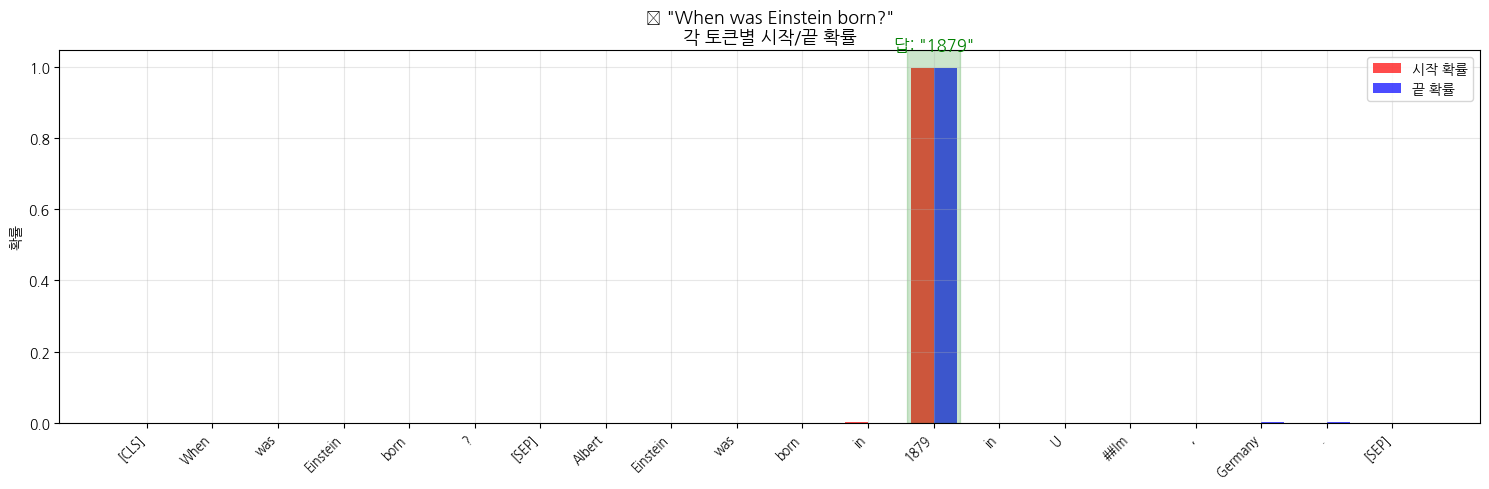

In [44]:
# 🔬 실제로 답의 위치를 시각화
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

qa_model_name = 'distilbert-base-cased-distilled-squad'
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
qa_model_inner = AutoModelForQuestionAnswering.from_pretrained(qa_model_name)

# 짧은 지문으로 실험
short_context = "Albert Einstein was born in 1879 in Ulm, Germany."
question = "When was Einstein born?"

# 토큰화
inputs = qa_tokenizer(question, short_context, return_tensors='pt')
tokens = qa_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# 모델 예측
with torch.no_grad():
    outputs = qa_model_inner(**inputs)
    start_logits = outputs.start_logits[0].numpy()
    end_logits = outputs.end_logits[0].numpy()

# Softmax로 확률화
start_probs = np.exp(start_logits) / np.exp(start_logits).sum()
end_probs = np.exp(end_logits) / np.exp(end_logits).sum()

# 시각화
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(len(tokens))
width = 0.35
ax.bar(x - width/2, start_probs, width, label='시작 확률', color='red', alpha=0.7)
ax.bar(x + width/2, end_probs, width, label='끝 확률', color='blue', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('확률')
ax.set_title(f'❓ "{question}"\n각 토큰별 시작/끝 확률', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 가장 높은 위치 표시
start_idx = np.argmax(start_probs)
end_idx = np.argmax(end_probs)
ax.axvspan(start_idx - 0.4, end_idx + 0.4, alpha=0.2, color='green')
ax.text((start_idx + end_idx) / 2, max(start_probs.max(), end_probs.max()) * 1.05,
        f'답: "{qa_tokenizer.decode(inputs["input_ids"][0][start_idx:end_idx+1])}"',
        ha='center', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

In [45]:
# 📚 더 긴 지문으로 한국 관련 QA 해보기 (영어로)
korea_context = """
Seoul is the capital and largest city of South Korea, with a population of about 9.7 million people.
It is the political, economic, and cultural center of the country. The Han River flows through the city.
Seoul hosted the 1988 Summer Olympics and the 2002 FIFA World Cup. The city is famous for its
modern technology, K-pop music, Korean BBQ, and historic palaces like Gyeongbokgung. The Korean
language uses Hangul, an alphabet invented by King Sejong in 1443.
"""

questions_korea = [
    "What is the capital of South Korea?",
    "What is the population of Seoul?",
    "What river flows through Seoul?",
    "When did Seoul host the Summer Olympics?",
    "Who invented Hangul?",
    "When was Hangul invented?",
]

print("📖 한국에 관한 지문")
print("-" * 60)

for q in questions_korea:
    answer = qa_pipe(question=q, context=korea_context)
    print(f"❓ {q}")
    print(f"💡 답: {answer['answer']:30s} (신뢰도: {answer['score']:.2%})")
    print()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


📖 한국에 관한 지문
------------------------------------------------------------
❓ What is the capital of South Korea?
💡 답: Seoul                          (신뢰도: 96.84%)

❓ What is the population of Seoul?
💡 답: 9.7 million                    (신뢰도: 71.54%)

❓ What river flows through Seoul?
💡 답: Han River                      (신뢰도: 53.98%)

❓ When did Seoul host the Summer Olympics?
💡 답: 1988                           (신뢰도: 95.82%)

❓ Who invented Hangul?
💡 답: King Sejong                    (신뢰도: 98.65%)

❓ When was Hangul invented?
💡 답: 1443                           (신뢰도: 96.76%)



## 🎯 빈칸 채우기 실습 #6

여러분이 좋아하는 주제로 지문을 만들고, BERT에게 질문해보세요!

In [48]:
# 🎯 실습 #6: 내 지문으로 QA 실행
# 자유롭게 지문을 작성하세요 (영어 권장)
my_context = """
Python is a high-level programming language created by Guido van Rossum
and first released in 1991. Python is known for its simple syntax and
readability. It is widely used in data science, web development, and
artificial intelligence. Major companies like Google, Netflix, and Instagram
use Python in their systems.
"""

my_question = "Who created Python?"

# TODO: 1. qa_pipe를 사용해 답을 구하세요
# 힌트: qa_pipe(question=..., context=...)
result = qa_pipe(question=my_question, context=my_context)

# TODO: 2. 결과에서 answer와 score를 추출하세요
answer_text = result['answer']  # 답 텍스트
confidence = result['score']    # 신뢰도

print(f"📖 지문:\n{my_context}")
print(f"❓ 질문: {my_question}")
print(f"💡 답: {answer_text}")
print(f"🎯 신뢰도: {confidence:.2%}")

📖 지문:

Python is a high-level programming language created by Guido van Rossum
and first released in 1991. Python is known for its simple syntax and
readability. It is widely used in data science, web development, and
artificial intelligence. Major companies like Google, Netflix, and Instagram
use Python in their systems.

❓ 질문: Who created Python?
💡 답: Guido van Rossum
🎯 신뢰도: 99.75%


<details>
<summary>🔑 정답 보기</summary>

```python
result = qa_pipe(question=my_question, context=my_context)
answer_text = result['answer']
confidence = result['score']
```

- `qa_pipe()`는 결과로 `{'answer': ..., 'score': ..., 'start': ..., 'end': ...}` 딕셔너리를 반환
- `'answer'`: 추출된 답 텍스트
- `'score'`: 답에 대한 신뢰도 (0~1)
- 더 많은 질문을 시도해보세요!

</details>

## 🧠 퀴즈 #4

QA에서 BERT는 답을 어떻게 결정하나요?

- A) 모든 가능한 답을 생성한 후 가장 좋은 것 선택
- B) 답의 **시작 위치**와 **끝 위치**의 확률을 계산
- C) 질문과 가장 유사한 문장 전체를 답으로 출력
- D) 지문을 요약하여 답으로 출력

<details>
<summary>👉 정답 보기</summary>

**B) 답의 시작 위치와 끝 위치의 확률을 계산**
- BERT는 지문에서 답이 **존재할 위치를 찾는** 방식 (추출적 QA)
- 답을 생성하는 게 아니라 **지문의 일부를 그대로 가져옴**
- 시작 확률이 가장 높은 위치 + 끝 확률이 가장 높은 위치 = 답 구간

</details>

### ✅ 체크포인트 7 - 실습 4 완료!

🎉 QA 실습 완료! 배운 것:
- QA는 **추출적**(extractive) 방식 - 지문에서 답을 그대로 가져옴
- BERT는 **시작/끝 위치의 확률**을 예측
- 사전학습 모델로 다양한 지문에 적용 가능

🎊 **모든 실습 완료!**

---
# 1️⃣2️⃣ BERT의 후예들 🚀

BERT(2018)는 엄청난 영향을 미쳤고, 수많은 **개량 모델**이 등장했어요.

## 🌟 주요 BERT 친구들

### 1. RoBERTa (2019, Facebook)
> **R**obustly **o**ptimized **BERT** approach
- "BERT를 더 빡세게 학습시켰더니 더 좋아졌네!"
- 변경점:
  - 더 많은 데이터 (10배)
  - 더 오래 학습
  - **NSP 제거** (효과 없다고 판단)
  - 동적 마스킹 (매번 다른 부분 마스킹)

### 2. ALBERT (2019, Google)
> **A** **L**ite **BERT**
- "BERT를 가볍게 만들자!"
- 변경점:
  - 임베딩 행렬 분해 (작게)
  - 레이어 간 파라미터 공유
  - NSP 대신 SOP (문장 순서 예측)
- BERT의 1/9 크기로 비슷한 성능!

### 3. ELECTRA (2020, Google)
> **E**fficiently **L**earning an **E**ncoder that **C**lassifies **T**oken **R**eplacements **A**ccurately
- "MLM은 비효율적, 다른 방법으로 학습하자!"
- **가짜 단어 탐지** 방식
  - 작은 모델이 단어를 살짝 바꿈
  - BERT가 어느 단어가 바뀌었는지 맞춤
- 같은 자원으로 BERT보다 훨씬 좋은 성능

### 4. DistilBERT (2019, Hugging Face)
> **Distil**led **BERT**
- "BERT를 압축해서 가볍게 쓰자!"
- 변경점:
  - BERT의 40% 작은 크기
  - 60% 빠른 추론
  - 97% 성능 유지
- **모바일·웹 서비스에 적합!**

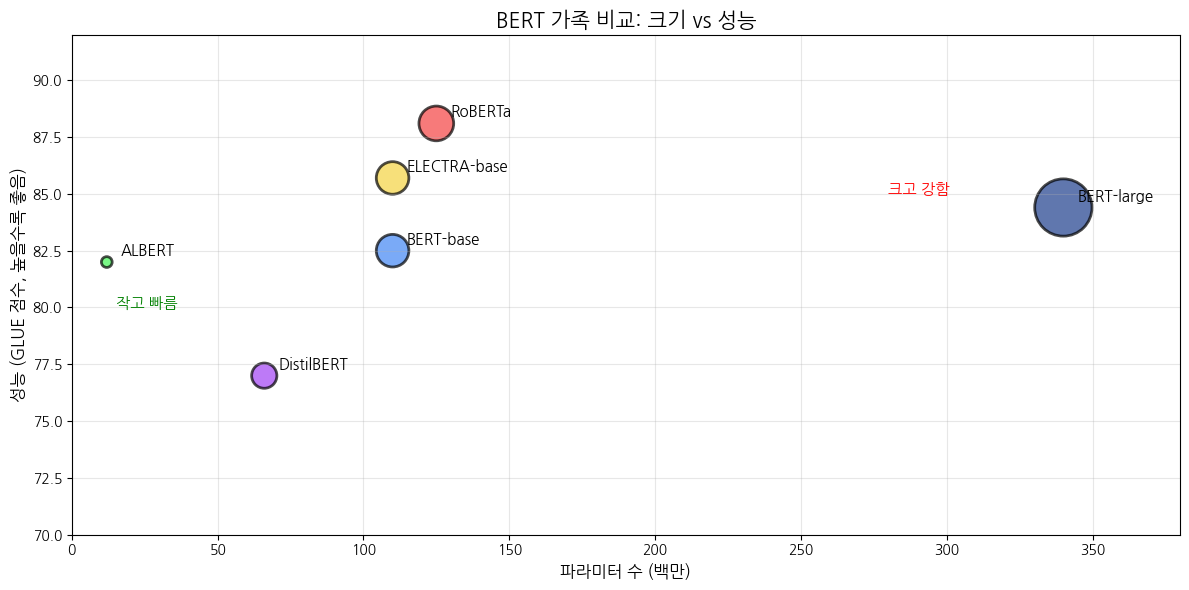


💡 ALBERT/DistilBERT: 가볍지만 성능 유지
💡 RoBERTa/ELECTRA: 같은 크기로 더 높은 성능


In [49]:
# 🎨 BERT 가족 비교 시각화
fig, ax = plt.subplots(figsize=(12, 6))

models = ['BERT-base', 'BERT-large', 'RoBERTa', 'ALBERT', 'ELECTRA-base', 'DistilBERT']
params = [110, 340, 125, 12, 110, 66]  # 백만 파라미터
glue_scores = [82.5, 84.4, 88.1, 82.0, 85.7, 77.0]  # GLUE 벤치마크 점수 (대략)

colors = ['#4287f5', '#1c3d8c', '#f54242', '#42f554', '#f5d442', '#a142f5']

scatter = ax.scatter(params, glue_scores, s=[p*5 for p in params],
                     c=colors, alpha=0.7, edgecolors='black', linewidth=2)

for i, model in enumerate(models):
    ax.annotate(model, (params[i], glue_scores[i]),
                xytext=(10, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax.set_xlabel('파라미터 수 (백만)', fontsize=12)
ax.set_ylabel('성능 (GLUE 점수, 높을수록 좋음)', fontsize=12)
ax.set_title('BERT 가족 비교: 크기 vs 성능', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 380)
ax.set_ylim(70, 92)

# 화살표로 트렌드 표시
ax.annotate('작고 빠름 ', xy=(15, 80), fontsize=11, color='green', fontweight='bold')
ax.annotate('크고 강함 ', xy=(280, 85), fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 ALBERT/DistilBERT: 가볍지만 성능 유지")
print("💡 RoBERTa/ELECTRA: 같은 크기로 더 높은 성능")

In [ ]:
# 🚀 DistilBERT로 같은 작업 빠르게 해보기
from transformers import pipeline

# DistilBERT 기반 감정 분석 (BERT보다 60% 빠름!)
distil_sentiment = pipeline('sentiment-analysis',
                             model='distilbert-base-uncased-finetuned-sst-2-english')

# 속도 비교
import time

sentences = ["I love this!", "Terrible product.", "It's okay.",
             "Amazing experience!", "Worst ever."] * 4  # 20개

start = time.time()
results = distil_sentiment(sentences)
elapsed = time.time() - start

print(f"⚡ DistilBERT로 {len(sentences)}개 문장 처리")
print(f"⏱️ 소요 시간: {elapsed:.3f}초")
print(f"📊 속도: {len(sentences)/elapsed:.1f} 문장/초")
print()
print("예시 결과 5개:")
for sent, res in zip(sentences[:5], results[:5]):
    emoji = "😊" if res['label'] == 'POSITIVE' else "😢"
    print(f"   {emoji} [{res['score']:.2%}] {sent}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

## 🇰🇷 한국어 BERT 모델

영어 BERT가 한국어를 잘 못해요. 한국어용 BERT 모델들이 따로 있습니다!

| 모델 | 특징 |
|------|------|
| **KoBERT** (SKT) | 한국어 위키 + 뉴스로 학습 |
| **KLUE/BERT** | 한국어 NLP 벤치마크용 BERT |
| **KcBERT** | 댓글 데이터로 학습 (구어체 강함) |
| **HanBERT** | 트위터·기사 등 다양한 한국어 |

> 💡 Colab에서는 `klue/bert-base`를 추천합니다 (성능과 사용성 균형).

In [ ]:
# 🇰🇷 한국어 BERT 맛보기 (선택사항 - 시간이 좀 걸려요)
try:
    from transformers import AutoTokenizer, AutoModelForMaskedLM
    import torch

    # 한국어 BERT 로드
    kor_tokenizer = AutoTokenizer.from_pretrained('klue/bert-base')
    kor_model = AutoModelForMaskedLM.from_pretrained('klue/bert-base')

    # 한국어 빈칸 채우기
    korean_sentences = [
        "나는 오늘 아침에 [MASK]을 먹었다.",
        "한국의 수도는 [MASK]이다.",
        "BERT는 [MASK]을 이해하는 모델이다.",
    ]

    print("🇰🇷 한국어 BERT MLM 결과")
    print("=" * 60)

    for sent in korean_sentences:
        inputs = kor_tokenizer(sent, return_tensors='pt')
        mask_idx = (inputs['input_ids'][0] == kor_tokenizer.mask_token_id).nonzero(as_tuple=True)[0]

        with torch.no_grad():
            outputs = kor_model(**inputs)

        # 상위 3개 예측
        logits = outputs.logits[0, mask_idx, :]
        probs = torch.softmax(logits, dim=-1)
        top3 = torch.topk(probs, 3, dim=-1)

        print(f"\n📝 문장: {sent}")
        print(f"💡 예측 (상위 3개):")
        for i in range(3):
            token_id = top3.indices[0, i].item()
            score = top3.values[0, i].item()
            word = kor_tokenizer.decode([token_id])
            print(f"   {i+1}. {word.strip():15s} ({score:.2%})")

except Exception as e:
    print(f"⚠️ 한국어 모델 로드 실패: {e}")
    print("💡 인터넷 연결을 확인하거나, 나중에 다시 시도해보세요.")

---
# 🎓 최종 정리

## 🌟 우리가 배운 것

### 🧠 BERT의 핵심 개념
1. **양방향 문맥 이해**: 단어의 앞뒤를 모두 봄
2. **사전학습 + 파인튜닝**: 일반 학습 → 특화 학습
3. **MLM + NSP**: 빈칸 채우기 + 문장 이어짐 판단

### 🛠️ BERT의 구성 요소
- **WordPiece 토크나이저**: 단어를 작은 조각으로
- **3가지 임베딩**: 토큰 + 위치 + 세그먼트
- **특수 토큰**: `[CLS]`, `[SEP]`, `[MASK]`, `[PAD]`, `[UNK]`

### 🎯 4가지 실습 완료!

| # | 실습 | 사용한 토큰 | 출력 |
|---|------|------------|------|
| 1 | 😊 감정 분류 | `[CLS]` | 긍정/부정 |
| 2 | 🏷️ 개체 태깅 (NER) | 모든 토큰 | 각 토큰의 태그 |
| 3 | 📏 문장 비교 (STS) | `[CLS]` (또는 SBERT) | 유사도 점수 |
| 4 | ❓ 질문 답변 (QA) | 모든 토큰 | 답의 시작/끝 위치 |

## 🚀 다음 단계 추천

### 1. 더 깊이 공부하고 싶다면
- **HuggingFace 코스**: https://huggingface.co/course
- **BERT 원논문**: "BERT: Pre-training of Deep Bidirectional Transformers"

### 2. 실전 프로젝트 아이디어
- 🎬 영화 리뷰 한국어 감정 분석기
- 📰 뉴스 기사 자동 분류기
- 🤖 도메인 특화 챗봇 (FAQ)
- 📊 SNS 댓글 분석 도구

### 3. 다른 모델 탐험
- **GPT 계열**: 문장 생성 (ChatGPT 기반)
- **T5**: 모든 작업을 텍스트 변환으로
- **LLaMA, Mistral**: 최신 오픈소스 LLM

## 🏆 축하합니다!

여러분은 이제:
- ✅ BERT가 어떻게 작동하는지 이해합니다
- ✅ 4가지 주요 NLP 작업을 BERT로 할 수 있습니다
- ✅ 자신의 데이터로 BERT를 파인튜닝할 수 있습니다
- ✅ 최신 NLP 트렌드를 따라갈 준비가 되었습니다

## 💡 마지막 조언

> 🎯 **"이론은 충분히 배웠어요. 이제 직접 만들어보세요!"**

가장 좋은 학습법은 **여러분의 프로젝트**를 만드는 것입니다.
작은 것부터 시작해서 점점 확장해 나가세요!

---

## 📚 참고 자료

- **BERT 논문**: [arxiv.org/abs/1810.04805](https://arxiv.org/abs/1810.04805)
- **HuggingFace**: [huggingface.co](https://huggingface.co)
- **Transformers 문서**: [huggingface.co/docs/transformers](https://huggingface.co/docs/transformers)
- **Sentence-Transformers**: [sbert.net](https://www.sbert.net)

---

### 🙏 감사합니다!

BERT 여정을 함께해주셔서 감사합니다. 즐거운 NLP 탐험 되세요! 🚀

> "The best way to learn is to build something." - Anonymous
